# Feature analysis — `vol_surge` (a fast/slow volatility-surge ratio, per exchange)

This notebook follows the project's standard feature-analysis **method** (the `template.ipynb`
worked example, `price_dislocation`) and applies it to one new feature, **`vol_surge`**. The
text explains what to do and why; the code does it.

We build features for a model that forecasts one exchange's mid-price about 100 ms ahead.
Three crypto exchanges appear throughout — **byb** (Bybit), **bin** (Binance), **okx** (OKX) —
and **byb is the target**: the one we predict. ("Mid-price" = the midpoint between the best
buy and best sell quote.) The next section recaps the two-head model these features feed.

**The feature, in one line.** `vol_surge = σ_ev(fast span) / σ_ev(slow span)` — take a venue's
**realized volatility per mid-move** `σ_ev` (the exp-weighted RMS of *that venue's* actual
mid-moves) at **two time-scales**, a *fast* one and a *slow* one, and divide them. A ratio above
1 means short-term volatility has surged above its slower baseline; below 1 means it's subsiding.
It's a **volatility-surge** detector, built entirely from the `σ_ev` machinery — reused at two spans.

**Per exchange, exactly as the template does for the gap.** Like `price_dislocation`, `vol_surge`
is built **the same way for every venue** and we **keep them all**: `vol_surge[byb]` reads byb's own
mid-moves, `vol_surge[okx]` okx's, `vol_surge[bin]` bin's — each on the one shared trade clock. The
target is always **byb's** next move. So byb's leg is byb's own vol surge predicting byb; the okx/bin
legs ask whether **another venue's** vol surge leads byb's. (Contrast the first pass, which built only
byb's leg.) §6 sweeps the heat-maps per venue, §9 runs per-exchange-vs-single.

**A feature is "done" when two checks pass:**
- **The oracle (§4)** — the optimized code really computes what we think it does, validated
  bit-exact against a dead-simple independent streaming implementation on a real block, **for every
  per-exchange leg**.
- **The hygiene gates (§5)** — the signal is real, and not just an echo of "the market is
  volatile right now."

> **Caveat up front — byb's leg IS (a re-parametrization of) a control; the cross-venue legs are
> not.** The §5 hygiene controls are built from **byb's** `σ_ev`: `vol_level = log σ_ev` and
> `vol_momentum = log(σ_ev_fast / σ_ev_slow)`. **`vol_surge[byb] ≡ exp(vol_momentum)`** at the
> matching spans — so "does `vol_surge[byb]` add over the vol controls" is **circular by
> construction** (≈ 0). But `vol_surge[okx]` and `vol_surge[bin]` are built from *other venues'*
> mid-moves — they are **NOT** circular with byb's controls, and asking whether they add marginal
> value is a genuine cross-venue lead/lag test. §5–§6–§9 surface both, and report the cross-venue
> marginal value **honestly**: it turns out to collapse to ≈ 0 (another venue's vol surge does not
> lead byb's move-rate once byb's own vol regime is controlled).

## The model these features feed: two heads

A feature is only worth something if it helps the model predict, so it's worth knowing what
the model does. We forecast how byb's mid-price moves over the next ~100 ms, and we split
that into two simpler questions — the two **heads**:

**Price head — which way and how far?** Over the next few price-moves, what is the *signed*
move (its direction *and* its size, together)? The head predicts the whole distribution of
that move in units of byb's recent **volatility** — the **volatility yardstick** `σ_ev` (the
exp-weighted RMS of byb's *actual* mid-moves) — so the head's target is `price change ÷ σ_ev`.

**Rate head — how many moves?** Busy markets pack many price-moves into the window, quiet ones
few. This head predicts the *count* of moves over the next 100 ms as a distribution, measured
against the recent pace — the **rate yardstick** `λ_ev` — so its target is `count ÷ λ_ev`.

**What's a yardstick?** A causal, trailing estimate of byb's *volatility* (`σ_ev`) and move
*rate* (`λ_ev`), from past data only. A regime gauge, nothing more. Both are EMAs **decayed on
the trade clock** (`α = 2/(span+1)`) but **updated between trades** — they react to every byb
mid-move, so they read live at every instant. They use one fixed span, `YARDSTICK_N`. (`σ_ev`
is the exp-weighted RMS of byb's *actual* mid-moves — read as an `E/W` ratio so the many
non-move trades cancel out; `λ_ev` is the exp-weighted byb move-count `W` ÷ the exp-weighted
seconds-per-trade = byb's moves per second.) Like every average here, they live on the
trade-tick clock — never wall-clock or a hard window. **The yardsticks are byb's** (the target's),
even when a feature leg reads another venue's volatility.

**Why split into two heads?** A move over a window is just *how many* little moves happen
times *how big* each one is. Pulling "how many" (rate) apart from "how big" (price) lets each
head learn a steadier thing — and is why there are two yardsticks, one per head. This is the
classic **subordination** decomposition (Clark, 1973; Ané & Geman, 2000): returns over a fixed
clock window become well-behaved once you condition on the *number* of events.

**Where `vol_surge` fits.** `vol_surge` is built from `σ_ev` — the **volatility** yardstick —
but it is *not* a direction signal: a vol ratio has no sign about which way byb moves. It is a
**rate-head (intensity)** feature. The mechanism: a sudden *surge* in per-move volatility is
the leading edge of a **volatility cluster**, and volatility clustering is tied to a burst of
trading — so a fast-over-slow `σ_ev` ratio above 1 should precede *more* byb moves in the next
100 ms. That is exactly the rate head's question. The per-exchange angle: does a vol surge on
**okx or bin** lead the same burst on byb? (We still test the price head too, as a diagnostic —
but the prior is that `vol_surge` carries little direction.)

## Guard rails — do this, not that

Hard rules, learned the hard way. Follow them unless you have a specific, written reason not to.

**Don't**
- **Don't assume a fixed leader.** No exchange always leads. Build the feature the same way for
  every exchange and keep them all — `vol_surge` is now per-venue (each reads its OWN mid-moves),
  exactly like the template's gap. Never hard-code byb as the leader.
- **Don't normalize reflexively.** `vol_surge` is **already a ratio** of two `σ_ev`'s, so it is
  dimensionless and comparable across calm/wild markets *by construction* — it needs **no**
  division by a yardstick. (Contrast `price_dislocation`, a raw gap, which did.) The normaliser
  gate in §5 confirms its scale is already steady; we do not add a redundant division.
- **Don't trust a correlation** until it survives the regime controls (rate and vol). **For byb's
  leg that gate is partly circular** — `vol_surge[byb]` *is* a vol control re-parametrized — so we
  read it as "is this a clean rate-head encoding of byb's vol regime," not "is it new information."
  **The okx/bin legs are NOT circular** — their marginal value is a real cross-venue test, reported
  honestly (it collapses to ≈ 0).
- **Don't ship a feature without the oracle** (§4) matching a dead-simple independent version — for
  **every** per-exchange leg.
- **Don't peek ahead.** Every value uses only data at-or-before its own timestamp.

**Do**
- **Do start with a falsifiable hypothesis** — here: a surge in per-move volatility precedes a
  burst of moves (rate head), and a surge on another venue may lead byb's. What disproves it: no
  rate-head power at any fast/slow pair, and no cross-venue marginal value.
- **Do make every average a trade-tick EMA.** *Every* smoother — all six `σ_ev` legs (three venues ×
  fast/slow) and the byb yardsticks — is an exponential moving average **decayed once per
  trade-timestamp** (`α = 2/(span+1)`) yet **updated on every live mid-move between trades**, **never**
  a wall-clock average and **never** a boxcar window. That keeps state **O(1)** and bit-identical
  online vs offline. The §4 oracle re-checks the convention against a plain event loop, per venue.
- **Do read a sparse flow as `E / W`.** Each venue's `σ_ev` is exactly such a flow — that venue
  moves on only *some* events — so each `σ_ev` leg is a **`KernelMeanEMA`**: push `r²` (weight `1`)
  only on a real mid-move of THAT venue, decay every trade, read `√(E/W)` = RMS move *per move*.
  Dividing by `W` cancels the foreign-event decay and the warm-up bias, leaving a per-move
  volatility comparable across regimes — and, crucially, a genuine **per-venue** statistic off the
  one shared clock. Push a `0` on a non-move trade instead and it silently becomes vol-per-*trade*.
- **Do treat all records sharing a timestamp as ONE event.** A burst of book updates and trades
  at the *exact same instant* is **one event** — `σ_ev` counts squared mid-*moves*, so N
  simultaneous records collapsed to one update avoids fabricating N−1 fake moves. The decay clock
  advances **once** per timestamp.
- **Do test against both heads — but the prior is rate.** `vol_surge` has no sign, so the price
  head is a diagnostic; the rate head is where it should live. We sweep both, every fast/slow
  pair, **every venue**, and let the data confirm.
- **Do score out-of-sample** with a purged, embargoed walk-forward (strictly past→future).
- **Do treat a feature as a family across time-scales AND exchanges** — here every (venue, fast
  σ_ev span, slow σ_ev span) — and let the data assign scales to heads and decide which venues add.

## 1. What the feature is, and why it might work

| | |
|---|---|
| **what** | a venue's realized volatility-per-move `σ_ev` at a *fast* span ÷ at a *slow* span — a volatility-surge ratio, built per exchange |
| **feeds** | primarily the **rate head** (intensity: how many byb moves next); price head tested as a diagnostic |
| **predicts** | byb's mid-price activity over the next 100 ms (chiefly the *count* of moves) |

**The idea.** For each venue, compute its per-move volatility `σ_ev` two ways — a *fast* EMA
(short memory, reacts within a handful of moves) and a *slow* EMA (long baseline) — and take the
ratio:

`vol_surge[ex] = σ_ev[ex](fast span) / σ_ev[ex](slow span)`

A ratio **> 1** says recent moves are bigger than the slow baseline — volatility is *surging*;
**< 1** says it's subsiding. Because both legs are `√(E/W)` over the *same* venue-move stream on
the *same* trade clock, the ratio is dimensionless and self-normalising — no yardstick division.

**Why it should work.** Volatility **clusters**: big moves come in bursts, and a burst of large
moves travels with a burst of *trading activity*. So a fast-over-slow `σ_ev` ratio that just
jumped above 1 is the leading edge of a cluster, and the cluster means **more byb moves in the
next 100 ms** — exactly the rate head's target. The **cross-venue** twist: if okx or bin surges
*first*, that surge might lead byb's burst — a per-exchange lead/lag like the template's gap. The
surge is (almost) sign-free, so it should not say much about *direction* (price head).

**What would disprove it.** No rate-head predictive power at any fast/slow pair (byb's leg), and
**no cross-venue marginal value** — i.e. okx's/bin's vol surge adds nothing over byb's own vol
regime.

> **Control-circularity (restated, because it governs how we read §5).** The §5 hygiene controls
> include `vol_momentum = log(σ_ev_fast / σ_ev_slow)` built from **byb's** `σ_ev`. `vol_surge[byb]`
> is `σ_ev[byb]_fast / σ_ev[byb]_slow`, so **`vol_surge[byb] ≡ exp(vol_momentum)`** at the matching
> spans — a monotone transform of a control. "Does `vol_surge[byb]` add over the vol controls?" is
> therefore close to "does X add over X?" — by construction ≈ 0. **That is byb's leg only.** The
> okx/bin legs are built from foreign mid-moves and carry no such circularity: their marginal value
> is the real question this per-exchange pass exists to answer.

## Choosing the EMA — the part that's easy to get silently wrong

Every smoother here is an EMA on the **trade clock**: its **decay** steps once per
*trade-timestamp* (`α = 2/(span+1)`), but its **value updates on every mid-move in between**,
so a read between trades is never stale.

`vol_surge` is built from exactly one kind of EMA, used **six** times (three venues × fast/slow):

- **A sparse flow** — a venue's squared mid-moves `r²`, present on only *some* events — uses
  **`KernelMeanEMA`**, the self-normalising `E / W`. The `W` denominator counts only the events
  that carry a move *for that venue*, so `E/W` is a *per-move mean* of `r²` and the many non-move
  trades cancel instead of counting as zeros. `σ_ev[ex] = √(E/W)`. We use **two per venue**,
  identical except for the span, both fed the *same* venue's `r²` stream and decayed on the *same*
  shared trade clock.

The injection rule that makes this correct: **push `r²` only on a real mid-move of THAT venue,
never a `0` on a non-move trade.** Pushing a zero would silently turn "vol per move" into "vol per
*trade*" (contaminated by the trade rate). Decay rides the shared trade clock; the read folds in
every move since the last trade so it is never stale; records sharing a timestamp collapse to one
mid update so no phantom moves are fabricated. The §4 oracle enforces all three, **per venue**.

Reading a sparse flow as `E/W` on the *shared* clock is also what makes a genuine **per-venue**
statistic possible from one clock: dividing by `W` cancels the foreign-event decay, so each
venue's `E/W` at span `N` approximates that venue's *own*-clock EMA at a rescaled span (the
merged↔own-clock equivalence `03_ema_clock_validation.ipynb` validates) — tight at large `N`,
fraying at small `N` where the cross-venue lead/lag lives.

## 2. The exact definition

A definition has to get three things right.

**Causal** — it uses only data up to the moment it's computed; no peeking. (A stray forward-fill
is the usual way to break this by accident; `σ_ev` reads the partial epoch of moves *since* the
last trade, never beyond the anchor.)

**Measured on the trade clock** — we count progress in *trades* (one tick per trade-timestamp on
any exchange — simultaneous prints are one tick), not clock-seconds. Mid-moves between trades
refresh what each `σ_ev` leg *reads*, but they do **not** advance the clock — only a trade does,
decaying each leg once. **All venues share this one clock**, so the per-venue `σ_ev`'s are
directly comparable.

**Comparable across calm and wild markets** — `vol_surge` is a **ratio of two `σ_ev`'s**, so it
is already dimensionless: a market that is 3× more volatile scales *both* legs by ≈3× and the
ratio is unchanged. **No yardstick division is applied** (and none is needed).

Put together:

**2a — The shape** (the whole idea, in one line, per venue):

`vol_surge[ex] = σ_ev[ex](fast span) / σ_ev[ex](slow span)`,  with  `σ_ev[ex](N) = √( E_N / W_N )`

where `E_N` is the span-`N` exp-weighted sum of *that venue's* squared mid-moves `r²` and `W_N`
the span-`N` exp-weighted move count, both on the shared trade clock.

**2b — The EMAs we use, and how they update:**

- **Both `σ_ev` legs, per venue** are a **sparse flow** read as `E / W` (a **`KernelMeanEMA`**
  each): push `r²` (weight `1`) only on a real mid-move of THAT venue, decay every trade-timestamp,
  read `√(E/W)`. The read at a grid anchor folds in the partial epoch of that venue's moves *since*
  the last trade. The two legs differ **only** in span (`fast`, `slow`); `fast < slow` always.
- **The yardsticks** `σ_ev`, `λ_ev` (span `YARDSTICK_N`) are byb's, built the same way and used to
  form the §5 controls and the rate-head **target** (`count ÷ λ_ev`). `vol_surge` itself uses *no*
  yardstick.

§3 builds exactly this with a vectorized `_flow_at` (parameterised by venue); §4 re-derives each
venue's leg from raw events with two `KernelMeanEMA`s and confirms bit-exact agreement.

The cell below loads the data, builds the shared trade clock, computes **each venue's** mid-move
stream, and builds byb's two yardsticks as `E/W` flows on that clock.

In [1]:
import numpy as np, polars as pl
import matplotlib.pyplot as plt
from scipy.signal import lfilter
from scipy.stats import spearmanr
from boba.io import list_blocks, load_block

COIN        = "eth_usdt_p"
TARGET      = "byb_eth_usdt_p"                    # the exchange we predict — byb's next move is always the target
EXCHANGES   = ["byb", "okx", "bin"]              # vol_surge is built per venue (each off its OWN mid-moves); we keep ALL (no fixed leader)
OTHERS      = ["okx", "bin"]                      # the CROSS-VENUE legs — not circular with byb's vol controls (the per-exchange test)
MID_STREAM  = {"bin": "front_levels", "byb": "merged_levels", "okx": "merged_levels"}   # freshest mid per venue (bin perp: merged_levels DISALLOWED)
FAST        = [50, 200, 1000, 3000]              # fast σ_ev spans — the WHOLE fast family is swept on the §6 heat-map (short vol memory)
SLOW        = [2000, 8000, 20000, 50000]         # slow σ_ev spans (the baseline; each must exceed the fast one) — the whole slow family too
HORIZON_NS  = 100 * 1_000_000                    # how far ahead we predict (100 ms, in nanoseconds)
YARDSTICK_N = 10000                              # the ONE span for BOTH byb yardsticks (σ_ev, λ_ev) — fixed, used for the controls + targets
block       = list_blocks(TARGET, "front_levels")[0]   # one ~24h slice of recorded data

# load each exchange's mid-price stream (rows already arrive in time order) — EACH feeds its OWN vol_surge leg
def load_mid(ex):
    df = (load_block(block, f"{ex}_{COIN}", MID_STREAM[ex]).select("rx_time", "bid_prc", "ask_prc").drop_nulls())
    return df["rx_time"].cast(pl.Int64).to_numpy(), (df["bid_prc"].to_numpy() + df["ask_prc"].to_numpy()) / 2
mids = {ex: load_mid(ex) for ex in EXCHANGES}

# the trade clock: one tick per trade-TIMESTAMP. Simultaneous prints (one order sweeping levels) are ONE event -> ONE tick.
trade_ts = []
for ex in EXCHANGES:
    td = (load_block(block, f"{ex}_{COIN}", "trade").select("rx_time", "prc", "qty")
          .filter((pl.col("prc") > 0) & (pl.col("qty") > 0)))         # drop bad prc=qty=0 prints
    trade_ts.append(td["rx_time"].cast(pl.Int64).to_numpy())
trade_prints = np.concatenate(trade_ts)
merged_ts = np.unique(trade_prints)                               # collapse same-timestamp prints: at most one decay per timestamp
n_ticks = len(merged_ts)
print(f"shared trade clock: {n_ticks:,} ticks (timestamps) from {len(trade_prints):,} trade prints")

# --- per-venue mid-move stream: the sparse flow EACH venue's σ_ev legs are built from ---
def move_stream(ex):                                                              # build THIS venue's r^2 flow + (for byb) the move count
    rx0, mid0 = mids[ex]
    keep = np.concatenate([rx0[1:] != rx0[:-1], [True]])                         # collapse same-TIMESTAMP rows to ONE update (the final mid): simultaneous events are not a sequence
    rx, mid = rx0[keep], mid0[keep]
    lm = np.log(mid)
    blr = np.empty_like(lm); blr[0] = 0.0; blr[1:] = np.diff(lm)                  # log-return per timestamp
    mv = blr != 0.0                                                              # a REAL mid-move: ONE per timestamp where the mid changed
    return rx[mv], blr[mv] ** 2, rx, mid, np.concatenate([[0.0], np.cumsum(mv.astype(float))])
MV = {}                                                                          # ex -> (move_rx, move_r2, collapsed_rx, collapsed_mid, cum_moves)
for ex in EXCHANGES:
    MV[ex] = move_stream(ex)
byb_rx, byb_mid, cum_mv = MV["byb"][2], MV["byb"][3], MV["byb"][4]               # byb's collapsed mid + running move count (rate-head target)

byb_dt = np.zeros(n_ticks); byb_dt[1:] = np.diff(merged_ts) / 1e9                # seconds between consecutive trades (per-trade)
def _ewma(x, span):                                                # per-trade EMA (for the seconds-per-trade leg of λ_ev)
    a = 2.0 / (span + 1.0); return lfilter([a], [1.0, -(1.0 - a)], x)
def _flow_at(anchors, mv_rx, val, span):    # EWMA of `val` over a venue's MOVE stream, decayed once per trade-timestamp, read AT each anchor (partial epoch since last trade folded in -> fresh)
    a = 2.0 / (span + 1.0)
    k = np.searchsorted(merged_ts, mv_rx, "left")                               # trades strictly before each move (a same-rx trade decays it)
    ep = np.bincount(k, weights=val, minlength=n_ticks + 1)                     # per-trade-epoch sums
    x = np.zeros(n_ticks + 1); x[1:] = a * (1.0 - a) * ep[:-1]
    com = lfilter([1.0], [1.0, -(1.0 - a)], x)                                  # committed E just after each trade
    ta = np.searchsorted(merged_ts, anchors, "right") - 1                       # last trade <= anchor
    cs = np.concatenate([[0.0], np.cumsum(val)])                               # prefix sums over the move stream (the partial epoch)
    partial = cs[np.searchsorted(mv_rx, anchors, "right")] - cs[np.searchsorted(mv_rx, merged_ts[ta], "right")]
    return com[ta + 1] + a * partial
def sigma_ev_at(ex, anchors, span):         # σ_ev[ex] at `span`: √(E/W) over THAT VENUE's move stream — the ONE primitive vol_surge reuses at two spans, per venue
    mv_rx, mv_r2 = MV[ex][0], MV[ex][1]
    e_sq = _flow_at(anchors, mv_rx, mv_r2, span)                  # E: exp-weighted squared moves of this venue
    e_mv = _flow_at(anchors, mv_rx, np.ones(mv_r2.size), span)   # W: exp-weighted move count of this venue
    return np.sqrt(e_sq / np.maximum(e_mv, 1e-12))               # RMS mid-move per move (E/W — non-moves cancel)
def yardsticks(anchors, span):                                     # σ_ev, λ_ev — BYB's model yardsticks (for controls + targets)
    mv_rx, mv_r2 = MV["byb"][0], MV["byb"][1]
    e_sq = _flow_at(anchors, mv_rx, mv_r2, span)
    e_mv = _flow_at(anchors, mv_rx, np.ones(mv_r2.size), span)
    e_dt = _ewma(byb_dt, span)[np.searchsorted(merged_ts, anchors, "right") - 1]  # seconds/trade (per-trade, held flat between trades)
    sig = np.sqrt(e_sq / np.maximum(e_mv, 1e-12))                 # σ_ev: RMS byb mid-move (E/W)
    lam = e_mv / np.maximum(e_dt, 1e-12)                          # λ_ev: byb mid-moves per second
    return sig, lam
for ex in EXCHANGES:
    print(f"  {ex}: {int(MV[ex][0].size):,} mid-moves of {int(MV[ex][2].size):,} updates carry a real move (its r^2 flow)")
print(f"yardsticks + all six vol_surge legs: react to every relevant mid-move; decay on the ONE shared trade clock")

shared trade clock: 1,682,255 ticks (timestamps) from 6,198,188 trade prints


  byb: 147,238 mid-moves of 1,726,152 updates carry a real move (its r^2 flow)
  okx: 128,848 mid-moves of 2,604,805 updates carry a real move (its r^2 flow)
  bin: 179,338 mid-moves of 9,350,160 updates carry a real move (its r^2 flow)
yardsticks + all six vol_surge legs: react to every relevant mid-move; decay on the ONE shared trade clock


## 3. Build it (twice)

Build the feature two ways: this fast array version for analysis, and — in production — a
streaming version that does constant work per trade (no growing buffers). They have to agree,
which §4 checks **for every venue**.

Here we lay an evaluation grid every 50 ms (half the 100 ms horizon — plenty of samples; note
that adjacent 100 ms outcome windows still overlap ~50%, so neighbouring samples are correlated,
which is exactly why §5's walk-forward gate uses an embargo), read byb's actual move over the
next 100 ms (the thing we're predicting), and compute `vol_surge` for **each venue** at each grid
point.

In [2]:
# evaluation grid (causal) + forward targets (price head in σ-units; rate head in λ-units)
WARMUP = 5 * max(YARDSTICK_N, max(SLOW))   # enough trades for the slowest EMA/yardstick to converge
anchor_ts      = np.arange(merged_ts[WARMUP], merged_ts[-1] - HORIZON_NS, 50 * 1_000_000)   # 50 ms grid, past warmup
tick_at_anchor = np.searchsorted(merged_ts, anchor_ts, "right") - 1                         # last trade-clock tick <= anchor
sigma_at_anchor, lam_at_anchor = yardsticks(anchor_ts, YARDSTICK_N)   # both BYB yardsticks at each grid point (span-YARDSTICK_N trade-tick EMA)
print(f"σ_ev median {np.nanmedian(sigma_at_anchor):.2e},  λ_ev median {np.nanmedian(lam_at_anchor):.2f} moves/s")

# price-head target (diagnostic for this feature): byb's 100 ms log-return ÷ σ_ev
mid_now    = byb_mid[np.searchsorted(byb_rx, anchor_ts, "right") - 1]
mid_fwd    = byb_mid[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right") - 1]
fwd_return = np.log(mid_fwd / mid_now)
target     = fwd_return / sigma_at_anchor                          # the price head's target (σ-units)

# vol_surge[ex]: σ_ev[ex](fast) / σ_ev[ex](slow) — the SAME √(E/W) primitive per venue at two spans, read at every grid anchor.
# CACHE σ_ev per (venue, span) (every span appears in many fast/slow pairs) so the sweep is cheap.
_sig_cache = {}
def sigma_ev(ex, span):
    if (ex, span) not in _sig_cache: _sig_cache[(ex, span)] = sigma_ev_at(ex, anchor_ts, span)
    return _sig_cache[(ex, span)]
def vol_surge(ex, n_fast, n_slow):                 # the feature, per venue: a dimensionless fast/slow vol ratio (NO yardstick division)
    return sigma_ev(ex, n_fast) / sigma_ev(ex, n_slow)
print(f"grid: {len(anchor_ts):,} anchors")
for ex in EXCHANGES:
    print(f"  vol_surge[{ex}](fast=200, slow=8000): median {np.nanmedian(vol_surge(ex, 200, 8000)):.3f}  (≈1 = calm; >1 = surging)")

σ_ev median 2.77e-05,  λ_ev median 1.14 moves/s


grid: 1,625,532 anchors


  vol_surge[byb](fast=200, slow=8000): median 0.920  (≈1 = calm; >1 = surging)


  vol_surge[okx](fast=200, slow=8000): median 0.926  (≈1 = calm; >1 = surging)


  vol_surge[bin](fast=200, slow=8000): median 0.918  (≈1 = calm; >1 = surging)


## 4. Check the code is right — the oracle (a production-style streaming build, per venue)

**Non-negotiable.** Reproduce the feature with a second, independent implementation and confirm the two
agree on real data — **for every per-exchange leg**. The oracle is the **production** reference: an O(1)
state machine you push **raw events** into — `on_book(...)` for a top-of-book update, `on_trade(...)`
for a trade — and read the current `vol_surge` from `value()`. State is just **two scalar
`KernelMeanEMA`s** (the fast and slow `σ_ev` legs) — no buffers, no history, independent of how long it
runs. We run **one builder per venue**, each targeting that venue's own listing.

**The design:**
- Fed **only raw events**, each tagged by its full listing and keyed by it, so a perp and a spot on one
  exchange stay separate books. Each builder builds its target venue's mid **itself** (merged venues fuse
  trades into the book by newest-exchange-time; bin is book-only) so the live mid matches the analysis mid;
  the other venues' events only drive the shared clock.
- Events sharing a **timestamp are one event**: the driver applies them all, then calls **`refresh()`
  once** per builder — which detects a target-venue mid-*move* and injects its `r²` into **both** `σ_ev`
  legs, then advances the clock **at most once** (decays both legs) and only if a trade landed. A
  book-only instant moves the mid (so the next move's `r²` is right) without advancing the clock.
- `value()` returns `√(E/W)_fast / √(E/W)_slow` — the current vol-surge ratio, fresh at the instant read.

We feed the **whole raw stream** — every venue's book updates and trades — into **all three** builders
in lock-step and read each `vol_surge[ex]` at each grid anchor. If every online build reproduces §3's
vectorized feature on real data, all are right. The two `σ_ev` legs share the move detection and the
trade clock, so this also re-validates the `σ_ev` machinery the yardsticks reuse.

In [3]:
import boba.io as io
import math
from boba.ema import KernelMeanEMA   # E/W flow mean — exactly σ_ev's estimator, src/boba/ema.py

class LiveVolSurge:
    # Pure feature state machine for ONE target venue. vol_surge = sqrt(E/W)_fast / sqrt(E/W)_slow, two
    # KernelMeanEMAs over the TARGET venue's squared mid-moves. on_book/on_trade only update that venue's bid/ask;
    # the driver calls refresh() ONCE per timestamp, which (a) detects a real target mid-move and injects its r^2 into
    # BOTH legs, then (b) advances the clock at most once (decay both legs) — only if a trade landed. State is O(1).
    # The mid is built INSIDE (never read from merged_levels): merged venues fuse trades by newest-exchange-time; bin book-only.
    def __init__(self, target, n_fast, n_slow, fuse_trades):
        self.target = target
        self.fuse_trades = set(fuse_trades)                                # listings whose mid folds in trades (merged); rest book-only
        self.bid = {}; self.bid_t = {}; self.ask = {}; self.ask_t = {}     # newest-by-exchange-time top-of-book, keyed by listing
        self.vf = KernelMeanEMA(n_fast)                                    # fast σ_ev leg: E/W of the target's r^2
        self.vs = KernelMeanEMA(n_slow)                                    # slow σ_ev leg
        self.prev = None                                                   # target's last log-mid, to detect a real move
        self.was_trade_present = False                                     # did a trade land this timestamp? -> exactly one decay per timestamp

    def _side(self, listing, is_ask, px, t):                              # keep this listing-side's newest-by-exchange-time price
        held_t = (self.ask_t if is_ask else self.bid_t)
        if t > held_t.get(listing, -1):
            (self.ask if is_ask else self.bid)[listing] = px; held_t[listing] = t

    def _mid(self, listing):
        b, a = self.bid.get(listing), self.ask.get(listing)
        return None if b is None or a is None else 0.5 * (b + a)

    def refresh(self):                                                    # ONE per TIMESTAMP: inject on a real target move, then advance the clock AT MOST ONCE (only if a trade landed)
        traded, self.was_trade_present = self.was_trade_present, False      # consume the flag — simultaneous prints = one decay, not many
        tgt = self._mid(self.target)
        if tgt is None: return
        lt = math.log(tgt)
        if self.prev is not None and lt != self.prev:
            r2 = (lt - self.prev) ** 2
            self.vf.add(r2); self.vs.add(r2)                          # BOTH σ_ev legs react to EVERY target mid-move — inject its return^2
        self.prev = lt
        if traded: self.tick()                                          # a trade landed -> advance the clock exactly once: decay both legs

    def on_book(self, listing, t, bid, ask):                              # BBO update -> mutate that listing's mid only (the single per-timestamp refresh is the driver's job)
        if listing in self.fuse_trades:
            self._side(listing, False, bid, t); self._side(listing, True, ask, t)
        else:
            self.bid[listing] = bid; self.ask[listing] = ask

    def on_trade(self, listing, t, px, lifts_ask):                       # trade -> fold into the mid (merged listings) and flag the timestamp as traded
        if listing in self.fuse_trades: self._side(listing, lifts_ask, px, t)
        self.was_trade_present = True

    def tick(self):                                                       # advance the trade clock ONE step: decay both σ_ev legs
        self.vf.tick(); self.vs.tick()

    def value(self):                                                      # the live vol-surge ratio: √(E/W)_fast / √(E/W)_slow (nan until both legs warm)
        ef, es = self.vf.value(), self.vs.value()
        if not (ef > 0.0) or not (es > 0.0): return float("nan")
        return math.sqrt(ef) / math.sqrt(es)

# --- gather the WHOLE raw stream (every venue's book updates + trades) over a slice; no merged_levels anywhere ---
NF, NS, N_GRID = 200, 8000, 40_000                 # validate one fast/slow pair over the first ~N_GRID grid points (reduced grid for speed; oracle still streams the real block) — for ALL venues
cutoff = int(anchor_ts[min(N_GRID, len(anchor_ts) - 1)])    # wall-clock time of the N_GRID-th grid anchor
LISTINGS = [f"{ex}_{COIN}" for ex in ("byb", "okx", "bin")] # 0=byb, 1=okx, 2=bin — integer codes keep the event arrays numeric & fast
cols = {k: [] for k in "rx kind lid t a b".split()}
def add(rx, kind, lid, t, a, b):                   # stage one source's events (kept ≤ cutoff)
    m = rx <= cutoff; n = int(m.sum())
    cols["rx"].append(rx[m]); cols["kind"].append(np.full(n, kind, np.int8)); cols["lid"].append(np.full(n, lid, np.int8))
    cols["t"].append(t[m]); cols["a"].append(a[m].astype(float)); cols["b"].append(b[m].astype(float))
for lid, ex in ((0, "byb"), (1, "okx")):           # merged-mid venues: raw front_levels (bid/ask + exchange_time), they fuse trades
    fl = load_block(block, f"{ex}_{COIN}", "front_levels").select("rx_time", "exchange_time", "bid_prc", "ask_prc").drop_nulls()
    add(fl["rx_time"].cast(pl.Int64).to_numpy(), 0, lid, fl["exchange_time"].cast(pl.Int64).to_numpy(), fl["bid_prc"].to_numpy(), fl["ask_prc"].to_numpy())
brx, bmid = mids["bin"]                             # book-only venue: bin's front_levels mid (already loaded in §2); fed as bid=ask=mid
add(brx, 0, 2, brx, bmid, bmid)
for lid, ex in ((2, "bin"), (0, "byb"), (1, "okx")):   # trades from EVERY venue tick the shared clock; byb/okx also fuse their mid
    td = load_block(block, f"{ex}_{COIN}", "trade").select("rx_time", "exchange_time", "prc", "qty", "aggressor").filter((pl.col("prc") > 0) & (pl.col("qty") > 0))
    add(td["rx_time"].cast(pl.Int64).to_numpy(), 1, lid, td["exchange_time"].cast(pl.Int64).to_numpy(),
        td["prc"].to_numpy(), io._trade_lifts_ask(f"{ex}_{COIN}", td["aggressor"].to_numpy()).astype(float))
C = {k: np.concatenate(v) for k, v in cols.items()}
order = np.lexsort((C["kind"], C["rx"]))           # rx ascending; book (0) before trade (1) on ties (matches merged_levels)
rxL, kindL, lidL, tL, aL, bL = (C[k][order].tolist() for k in "rx kind lid t a b".split())
print(f"streaming {len(rxL):,} raw events (book + trades, all venues) over ~{N_GRID:,} grid points, ALL THREE venues...")

# --- the CALLER drives all three builders in lock-step: apply each timestamp's events, refresh() each once, READ value() at every anchor ---
fuse = {f"{ex}_{COIN}" for ex in EXCHANGES if MID_STREAM[ex] == "merged_levels"}   # byb,okx merged; bin book-only
feats = {ex: LiveVolSurge(f"{ex}_{COIN}", NF, NS, fuse) for ex in EXCHANGES}        # one builder per venue, each targeting its OWN listing
na = min(N_GRID, len(anchor_ts))                                                    # the validated grid slice
streams = {ex: np.full(na, np.nan) for ex in EXCHANGES}
n = len(rxL); i = 0; ai = 0
while i < n:                                        # walk the stream, grouped by receive-timestamp
    rx = rxL[i]
    while ai < na and anchor_ts[ai] < rx:          # read every anchor whose state is settled (all events before rx applied)
        for ex in EXCHANGES: streams[ex][ai] = feats[ex].value()
        ai += 1
    while i < n and rxL[i] == rx:                  # apply EVERY event stamped at this nanosecond (no half-applied timestamp) to ALL builders
        lst = LISTINGS[lidL[i]]
        if kindL[i] == 0:
            for ex in EXCHANGES: feats[ex].on_book(lst, tL[i], aL[i], bL[i])
        else:
            for ex in EXCHANGES: feats[ex].on_trade(lst, tL[i], aL[i], bL[i])
        i += 1
    for ex in EXCHANGES: feats[ex].refresh()       # apply the timestamp to each builder: inject on its move, then advance the clock ONCE if any trade landed
while ai < na:                                     # trailing anchors after the last event
    for ex in EXCHANGES: streams[ex][ai] = feats[ex].value()
    ai += 1

# --- check EVERY venue's streaming feature against its §3 vectorized build, bit-exact ---
print(f"one raw-event stream -> per-venue vol_surge, vs the vectorized build (fast={NF}, slow={NS}):")
worst = 0.0
for ex in EXCHANGES:
    ref = vol_surge(ex, NF, NS)[:na]
    both = np.isfinite(streams[ex]) & np.isfinite(ref)
    diff = np.abs(streams[ex][both] - ref[both]); mx = float(np.nanmax(diff)); worst = max(worst, mx)
    print(f"  {ex}:  max |diff| {mx:.2e}  on {int(both.sum()):,} grid points  -> {'OK' if mx < 1e-9 else 'FAIL'}")
    assert mx < 1e-9, f"live build does not reproduce vol_surge[{ex}]"
print(f"oracle: streaming build reproduces vol_surge bit-exact for ALL venues (worst {worst:.2e})  OK")

streaming 6,115,149 raw events (book + trades, all venues) over ~40,000 grid points, ALL THREE venues...


one raw-event stream -> per-venue vol_surge, vs the vectorized build (fast=200, slow=8000):
  byb:  max |diff| 1.01e-12  on 40,000 grid points  -> OK
  okx:  max |diff| 3.66e-13  on 40,000 grid points  -> OK
  bin:  max |diff| 6.98e-13  on 40,000 grid points  -> OK
oracle: streaming build reproduces vol_surge bit-exact for ALL venues (worst 1.01e-12)  OK


**Conclusion.** From the raw-event stream the O(1) builder reproduces the vectorized `vol_surge` to
floating-point precision **for every venue** — max |diff| at round-off level over the grid slice, pure
last-digit drift from the EMAs' recursion. Each venue's two `σ_ev` legs share that venue's move detection,
the `r²` injection rule, and the one shared trade clock, so this also re-validates the `σ_ev` machinery the
byb yardsticks are built from. The §3 build is trustworthy for all three legs.

## 5. Is the signal real? — the hygiene gates (read through the control-circularity caveat)

A correlation is an easy way to fool yourself. The gates check that the feature predicts
*something the market's current state doesn't already tell us*. We build four "control" signals
from the recent past, **all from byb** (the target):
- **rate momentum** and **rate level** — both from `λ_ev` (byb's mid-move rate).
- **vol momentum** and **vol level** — both from byb's `σ_ev` (byb's volatility).

**Here is the catch, and it is central to this feature.** `vol_momentum = log(σ_ev[byb]_fast /
σ_ev[byb]_slow)` and `vol_level = log σ_ev[byb]`. **`vol_surge[byb] = σ_ev[byb]_fast /
σ_ev[byb]_slow = exp(vol_momentum)`** at the matching spans — byb's leg is a *monotone transform of
a control*. So the marginal-value gate for **byb's leg** ("does `vol_surge[byb]` add over the
controls?") is **circular by construction**: ≈ 0, and that near-zero is the *expected, correct*
answer. **The okx/bin legs are different.** They are built from *other venues'* mid-moves, so they
carry **no** circularity with byb's controls — their marginal value is a genuine **cross-venue
lead/lag** test: does a vol surge on okx or bin lead byb's move-rate? We run it honestly and report
the number; the answer (below and in §9) is that it **collapses to ≈ 0** — another venue's vol
surge adds essentially nothing once byb's own vol regime is in.

"Predictive power" here is the **rank correlation** (Spearman) scored **out-of-sample with a
purged, embargoed, expanding-window walk-forward** (strictly past→future) — the same gate the
template uses. We report it for **both** targets, but the **rate head** is `vol_surge`'s home (a
vol ratio has no direction), so it is the one to weigh.

In [4]:
# --- the four control signals: BYB's two yardsticks (level) plus a fast/slow momentum of each ---
FAST_YARD = YARDSTICK_N // 10                        # a faster span (1/10 the yardstick) for the momentum controls
sig_fast, lam_fast = yardsticks(anchor_ts, FAST_YARD)
vol_level     = np.log(sigma_at_anchor)                                             # σ_ev[byb] — how volatile byb is now
vol_momentum  = np.log(sig_fast / sigma_at_anchor)                                  # recent byb vol vs slower == log(vol_surge[byb] at THESE spans): byb's leg IS this control re-parametrized
rate_level    = np.log(lam_at_anchor)                                               # λ_ev = byb's mid-move rate
rate_momentum = np.log(lam_fast / lam_at_anchor)                                    # recent rate vs slower rate

# rate-head target = byb moves (on the trade clock) in the next 100 ms, divided by λ_ev (the rate yardstick).
fwd_count = (cum_mv[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right")]
             - cum_mv[np.searchsorted(byb_rx, anchor_ts, "right")])            # byb mid-moves over the next 100 ms
rate_target = fwd_count / np.maximum(lam_at_anchor, 1e-9)                      # count ÷ λ_ev — "more/fewer moves than usual" (the rate-head target)

# Out-of-sample scoring = a purged, expanding-window WALK-FORWARD (causal: only past -> future).
def wf_folds(features, y, k=6, embargo=2000):       # yields (test_mask, oos_prediction) for each fold
    design = np.column_stack(features); n = len(y); valid = np.isfinite(design).all(1) & np.isfinite(y)
    edges = np.linspace(0, n, k + 1).astype(int)
    for i in range(1, k):                            # fold i: train on the PAST minus an embargo gap, test on the next segment
        te = np.zeros(n, bool); te[edges[i]:edges[i + 1]] = True
        tr = np.zeros(n, bool); tr[:max(0, edges[i] - embargo)] = True   # embargo clears the 100 ms outcome windows with margin
        train, test = valid & tr, valid & te
        if train.sum() < 100 or test.sum() < 100: continue
        mu, sd = design[train].mean(0), design[train].std(0) + 1e-12
        X = np.column_stack([(design - mu) / sd, np.ones(n)])
        coef, *_ = np.linalg.lstsq(X[train], y[train], rcond=None)
        yield test, X @ coef

def wf_ic(features, y):                              # mean OOS rank-IC across the walk-forward folds (the ship-grade gate)
    return float(np.mean([spearmanr(p[t], y[t]).statistic for t, p in wf_folds(features, y)]))
def wf_ic_by_regime(features, y, reg):              # same, but the mean OOS rank-IC WITHIN each regime bucket (the companion)
    acc = {}
    for t, p in wf_folds(features, y):
        for r in np.unique(reg[t]):
            m = t & (reg == r)
            if m.sum() >= 100: acc.setdefault(int(r), []).append(spearmanr(p[m], y[m]).statistic)
    return {r: float(np.mean(v)) for r, v in acc.items()}

vol_regime = np.digitize(vol_level, np.nanpercentile(vol_level[np.isfinite(vol_level)], [33, 67]))   # 0 calm, 1 mid, 2 wild
base, levels = [rate_momentum, vol_momentum], [rate_level, vol_level]   # momenta = base controls; levels added later for the leak test
print("control-only predictive power (walk-forward) — RATE head:  momenta", round(wf_ic(base, rate_target), 3),
      " momenta+levels", round(wf_ic(base + levels, rate_target), 3))
print("control-only predictive power (walk-forward) — PRICE head:", round(wf_ic(base, target), 3),
      "(controls barely predict DIRECTION; rate is where the vol controls — and vol_surge — live)")

control-only predictive power (walk-forward) — RATE head:  momenta 0.072  momenta+levels 0.06


control-only predictive power (walk-forward) — PRICE head: -0.002 (controls barely predict DIRECTION; rate is where the vol controls — and vol_surge — live)


**Conclusion.** The controls carry **real rate-head power** (the vol/rate momenta *do* predict how many
moves come next — that is what `λ_ev`/`σ_ev` are for) but essentially **no** price-head/direction power.
This sets up the caveat: because `vol_surge[byb] ≡ exp(vol_momentum)`, **byb's leg** lives in the *same
space* as the rate-head controls, so it cannot add much over them — by construction, not a defect. The
**okx/bin legs do not share that space** — they are tested for genuine cross-venue marginal value below.
Read byb's marginal-over-controls as the circularity check, the cross-venue legs' as the real test, and
the **raw** rate-head IC as each venue's actual standalone contribution.

## 6. Two choices: which time-scale per head, and which exchanges to keep

A feature is a **family** across time-scales (here every fast/slow `σ_ev` pair) **and across
exchanges** (each venue's own vol surge). We check both heads, but with a strong prior:
- **rate head (intensity)** — does `vol_surge` (a ratio ≥ 0, so effectively its level) predict
  *how many* byb moves come next? **This is `vol_surge`'s home.**
- **price head (direction)** — does it predict *which way* byb moves? A vol ratio has no sign, so
  the prior is ≈0; we sweep it only as a diagnostic.

**Exchanges — kept all, swept symmetrically.** `vol_surge` is now built per venue (each off its own
mid-moves), exactly like the template's gap. We build it the **same way for every venue** and **keep
them all** — never pick "the best exchange." The full **fast × slow** span family is swept on the
heat-map **for every venue and both heads**, and we pick the best (fast, slow) **per venue, per head**
off the grid. byb's column is the circular (own-vol) leg; the okx/bin columns are the cross-venue legs.

**How many venues to keep is time-scale-dependent** (the same lead/lag logic as the template): at
**short** lookback the venues genuinely differ (whose vol is surging first), so a per-exchange split
can carry distinct information; at **long** lookback every venue carries the same slow vol regime and
one suffices — §9 sweeps that cross-over explicitly.

The rate-head target is the count of byb's moves over the next 100 ms ÷ `λ_ev`; the price-head target
is byb's 100 ms return ÷ `σ_ev`.

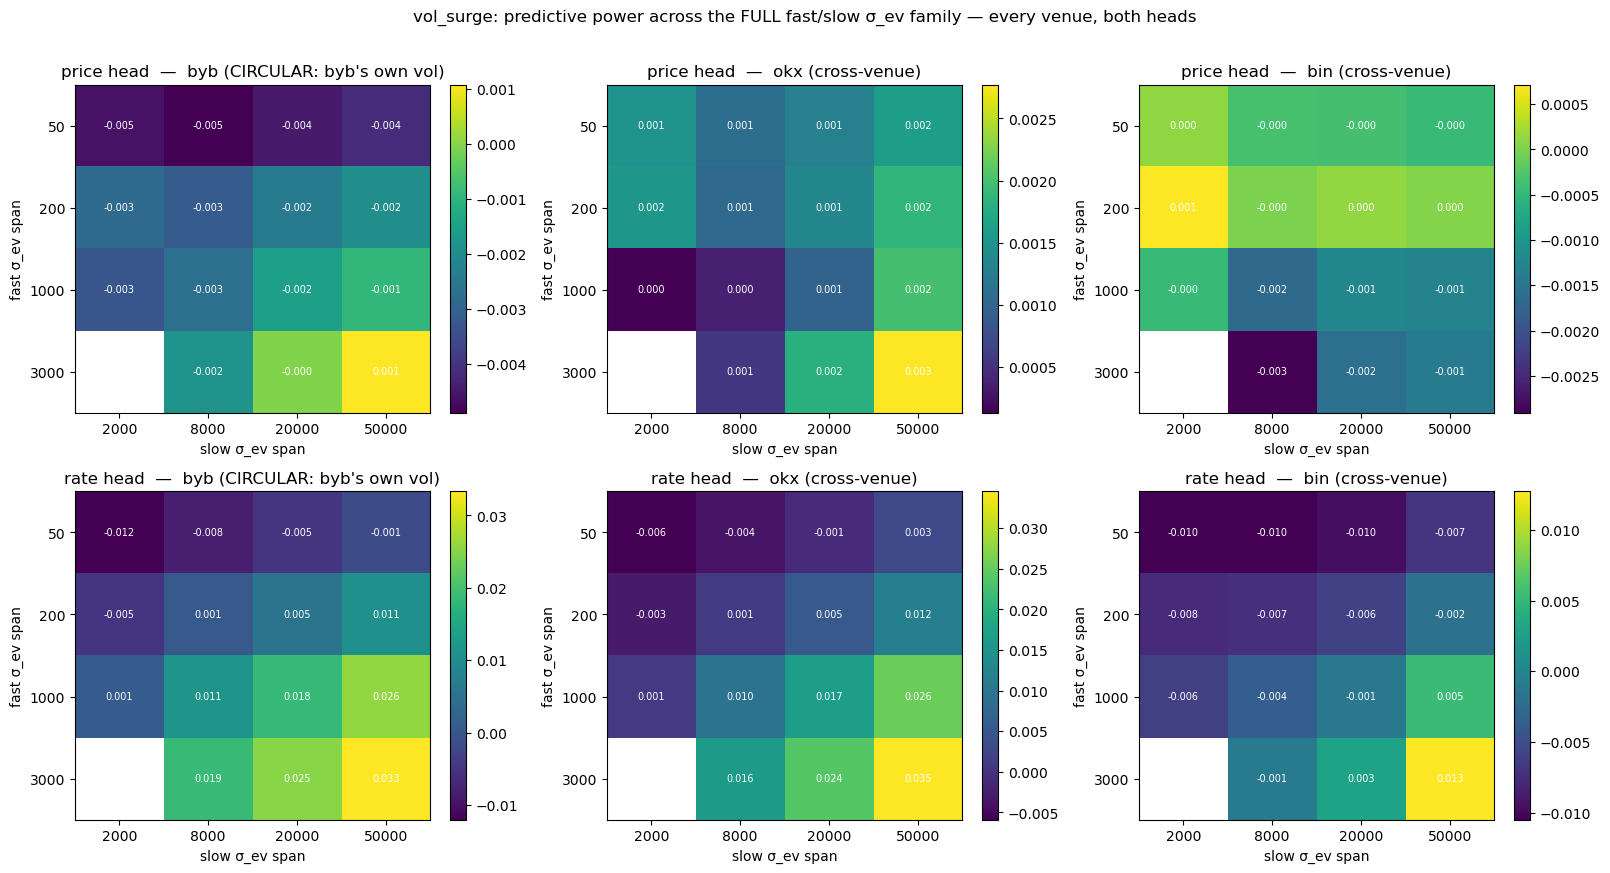

picked spans off the full grid (per venue, per head):
  byb [CIRCULAR (byb own vol)]:  rate head fast=3000 slow=50000 IC=+0.033   |  price head fast=3000 slow=50000 IC=+0.001
  okx [         cross-venue]:  rate head fast=3000 slow=50000 IC=+0.035   |  price head fast=3000 slow=50000 IC=+0.003
  bin [         cross-venue]:  rate head fast=3000 slow=50000 IC=+0.013   |  price head fast= 200 slow= 2000 IC=+0.001


In [5]:
# Sweep the WHOLE fast×slow family, BOTH heads, for EVERY venue (symmetric; keep all). Diagnostic in-sample
# rank-IC at each cell (used ONLY to PICK a time-scale per venue/head; the pick is re-scored OOS in the gates).
price_grid = {ex: np.full((len(FAST), len(SLOW)), np.nan) for ex in EXCHANGES}   # signed feature -> byb's signed return (expect weak: a vol ratio has no direction)
rate_grid  = {ex: np.full((len(FAST), len(SLOW)), np.nan) for ex in EXCHANGES}   # feature level -> byb's move count (the home head)
for ex in EXCHANGES:
    for i, nf in enumerate(FAST):
        for j, ns in enumerate(SLOW):
            if nf >= ns: continue
            vs = vol_surge(ex, nf, ns)
            price_grid[ex][i, j] = spearmanr(vs, target).statistic
            rate_grid[ex][i, j]  = spearmanr(vs, rate_target).statistic    # vol_surge >=0, so its level (not |·|) is the natural intensity readout

# heat-map: rows = heads, columns = venues — the whole fast×slow grid per cell
fig, axes = plt.subplots(2, len(EXCHANGES), figsize=(5.4 * len(EXCHANGES), 8.6), squeeze=False)
for row, (grids, head) in enumerate([(price_grid, "price head: vol_surge -> signed return  (diagnostic; expect ≈0)"),
                                     (rate_grid,  "rate head: vol_surge -> move count  (the home head)")]):
    for col, ex in enumerate(EXCHANGES):
        ax = axes[row][col]; grid = grids[ex]; im = ax.imshow(grid, cmap="viridis", aspect="auto")
        ax.set_xticks(range(len(SLOW))); ax.set_xticklabels(SLOW); ax.set_xlabel("slow σ_ev span")
        ax.set_yticks(range(len(FAST))); ax.set_yticklabels(FAST); ax.set_ylabel("fast σ_ev span")
        circ = " (CIRCULAR: byb's own vol)" if ex == "byb" else " (cross-venue)"
        ax.set_title(f"{head.split(':')[0]}  —  {ex}{circ}")
        for i in range(len(FAST)):
            for j in range(len(SLOW)):
                if np.isfinite(grid[i, j]): ax.text(j, i, f"{grid[i, j]:.3f}", ha="center", va="center", color="w", fontsize=7)
        fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("vol_surge: predictive power across the FULL fast/slow σ_ev family — every venue, both heads", y=1.01)
fig.tight_layout(); plt.show()

# pick the best (fast, slow) PER VENUE, PER HEAD off the grid (in-sample pick; re-scored OOS in the §5 gates)
def best_member(grid): return np.unravel_index(np.nanargmax(grid), grid.shape)
price_member = {ex: best_member(price_grid[ex]) for ex in EXCHANGES}
rate_member  = {ex: best_member(rate_grid[ex])  for ex in EXCHANGES}
print("picked spans off the full grid (per venue, per head):")
for ex in EXCHANGES:
    pi, pj = price_member[ex]; ri, rj = rate_member[ex]
    tag = "CIRCULAR (byb own vol)" if ex == "byb" else "cross-venue"
    print(f"  {ex:>3} [{tag:>20}]:  rate head fast={FAST[ri]:>4} slow={SLOW[rj]:>5} IC={rate_grid[ex][ri, rj]:+.3f}"
          f"   |  price head fast={FAST[pi]:>4} slow={SLOW[pj]:>5} IC={price_grid[ex][pi, pj]:+.3f}")

### IC is only half the story — **signal lifetime** across the same family

The heat-map above ranks the `(fast, slow)` family by **headline IC** — the edge you'd see if you
could act at the anchor with zero latency. But a feature can be perfectly causal and still not earn
that headline: if its edge is the move *already underway* at the anchor, by the time you observe,
decide and act it is gone. So for **every** member of the family we also measure **how long the edge
lasts** — exactly the companion further down, but swept across the *whole* grid instead of at one
chosen span.

For each `(venue, fast, slow)` cell, for each head, we read the feature at the anchor (causal,
unchanged) but slide the *outcome* window forward by an observe→act latency `δ`, and record:
- **forward IC at δ=0** — the headline (zero-latency) edge;
- **forward IC at δ=20 ms** — the edge that survives a realistic ~20 ms observe→act budget;
- **half-life** — the smallest `δ` (ms) where the forward IC first falls **below half** its δ=0
  value (`>500 ms` if it never does, i.e. the edge is *long-lived*);
- **backward IC** — the feature vs the move that *already happened* (`[anchor−100ms, anchor]`),
  which sizes the **contemporaneous echo**.

**The key trade-off this surfaces.** Different `N` in the *same* family trade **IC against
half-life**. A **short** fast/slow pair reacts to the freshest surge — it can have a higher δ=0 IC
but a **short** half-life (a small latency budget: act fast or lose it). A **long** pair carries the
slow vol regime — a **lower** IC but a **long** half-life (a generous budget; vol clustering persists
tens to hundreds of ms). **Both can be useful**, so we draw IC, edge@20 ms *and* half-life as
side-by-side heat-maps per head/venue, and suggest **more than one** lookback per head when the
family genuinely offers the short-high-IC vs long-high-half-life choice.

**The honest read for `vol_surge`.** A head only "carries signal" if some span has a forward IC at
δ=20 ms that is **clearly nonzero and not dominated by the backward (echo) IC**. For `vol_surge` the
numbers are *small* and, where the IC is largest, **forward(δ=20 ms) ≈ forward(δ=0) ≈ backward** —
the flat-across-δ shape of a long-lived vol cluster that is **mostly a contemporaneous read of byb's
own activity** rather than a forward lead. The half-life heat-map will therefore read `>500 ms`
across most of the family (the IC barely changes with δ) — long-lived, but echo-heavy. We state that
per head below; the diagnostic grid (40k anchors) is a *window* of the block, so the magnitudes here
are window-specific (the full-block §6 IC for byb's rate head is ≈0 — see §5/§9), but the *shape*
(flat-across-δ, forward≈backward) is the load-bearing fact.

In [6]:
# ===== signal LIFETIME across the WHOLE fast/slow family — per head, per venue (40k-anchor DIAGNOSTIC grid for speed) =====
# For each (venue, fast, slow) cell and each head, slide the OUTCOME window forward by δ and record:
#   forward IC @ δ=0, forward IC @ δ=20 ms, HALF-LIFE (first δ where |IC| < |IC(δ=0)|/2; >500 if never), backward (echo) IC.
DELTAS_MS = [0, 5, 10, 20, 50, 100, 200, 500]                      # observe->act latencies to sweep the outcome window over
NDIAG     = min(40_000, len(anchor_ts))                            # the 40k-anchor diagnostic grid (a fast window of the full §6 grid)
diag      = anchor_ts[:NDIAG]

# σ_ev[ex] on the DIAGNOSTIC grid, cached per (venue, span) — every span shows up in many fast/slow pairs
_sigd = {}
def sigma_ev_diag(ex, span):
    if (ex, span) not in _sigd: _sigd[(ex, span)] = sigma_ev_at(ex, diag, span)
    return _sigd[(ex, span)]
def vol_surge_diag(ex, nf, ns): return sigma_ev_diag(ex, nf) / sigma_ev_diag(ex, ns)

def _ic(feat, ret):                                               # rank-IC over the finite overlap
    v = np.isfinite(feat) & np.isfinite(ret)
    return spearmanr(feat[v], ret[v]).statistic if v.sum() > 100 else float("nan")
def _mid_at(t):  return byb_mid[np.clip(np.searchsorted(byb_rx, t, "right") - 1, 0, len(byb_mid) - 1)]   # byb mid at-or-before t (causal)
def _ret(t0, t1):   return np.log(_mid_at(t1) / _mid_at(t0))                                              # byb signed return over [t0,t1] (price head)
def _count(t0, t1): return cum_mv[np.searchsorted(byb_rx, t1, "right")] - cum_mv[np.searchsorted(byb_rx, t0, "right")]  # byb move count (rate head)

# precompute the forward outcome at each δ + the backward (already-happened) outcome, ONCE — both heads share the same δ grid
fwd_count_d = {d: _count(diag + d*1_000_000, diag + d*1_000_000 + HORIZON_NS) for d in DELTAS_MS}
fwd_ret_d   = {d: _ret  (diag + d*1_000_000, diag + d*1_000_000 + HORIZON_NS) for d in DELTAS_MS}
back_count_d = _count(diag - HORIZON_NS, diag)                    # rate-head echo
back_ret_d   = _ret  (diag - HORIZON_NS, diag)                    # price-head echo
HEADS = {"rate": (fwd_count_d, back_count_d),                     # rate head: feature LEVEL (>=0) -> byb move count (HOME)
         "price": (fwd_ret_d,   back_ret_d)}                      # price head: signed feature -> byb signed return (diagnostic)

def half_life(ics):                                               # first δ (ms) where |forward IC| drops below half its δ=0 value; >500 -> 999 sentinel
    ic0 = ics[0]
    if not np.isfinite(ic0) or ic0 == 0.0: return float("nan")
    for d, ic in zip(DELTAS_MS, ics):
        if np.isfinite(ic) and abs(ic) < abs(ic0) / 2.0: return d
    return 999                                                    # never halves over the swept δ -> long-lived (>500 ms)

# sweep: per head, per venue, fill (fast x slow) grids of IC@0, IC@20ms, half-life, backward IC
ic0_grid   = {h: {ex: np.full((len(FAST), len(SLOW)), np.nan) for ex in EXCHANGES} for h in HEADS}
ic20_grid  = {h: {ex: np.full((len(FAST), len(SLOW)), np.nan) for ex in EXCHANGES} for h in HEADS}
half_grid  = {h: {ex: np.full((len(FAST), len(SLOW)), np.nan) for ex in EXCHANGES} for h in HEADS}
back_grid  = {h: {ex: np.full((len(FAST), len(SLOW)), np.nan) for ex in EXCHANGES} for h in HEADS}
for h, (fwd_d, back_d) in HEADS.items():
    for ex in EXCHANGES:
        for i, nf in enumerate(FAST):
            for j, ns in enumerate(SLOW):
                if nf >= ns: continue
                f = vol_surge_diag(ex, nf, ns)                    # the feature level (rate head reads it as-is; price head reads the signed return outcome)
                ics = [_ic(f, fwd_d[d]) for d in DELTAS_MS]        # forward IC curve over δ
                ic0_grid[h][ex][i, j]  = ics[0]
                ic20_grid[h][ex][i, j] = ics[DELTAS_MS.index(20)]
                half_grid[h][ex][i, j] = half_life(ics)
                back_grid[h][ex][i, j] = _ic(f, back_d)
print(f"lifetime sweep done on {NDIAG:,}-anchor diagnostic grid (δ ∈ {DELTAS_MS} ms), both heads, all venues")

lifetime sweep done on 40,000-anchor diagnostic grid (δ ∈ [0, 5, 10, 20, 50, 100, 200, 500] ms), both heads, all venues


**The three heat-maps, side by side, per head and venue.** For each head we show, across the same
`fast × slow` grid: the **headline IC (δ=0)**, the **edge that survives δ=20 ms**, and the
**half-life** (ms; capped at `>500`). Read them together — a cell wins if it has *both* a non-trivial
δ=20 ms edge *and* a long half-life, or trades one for the other. The **backward** (echo) IC is
printed beneath so you can see where the δ=0 IC is just re-reporting the move already underway.

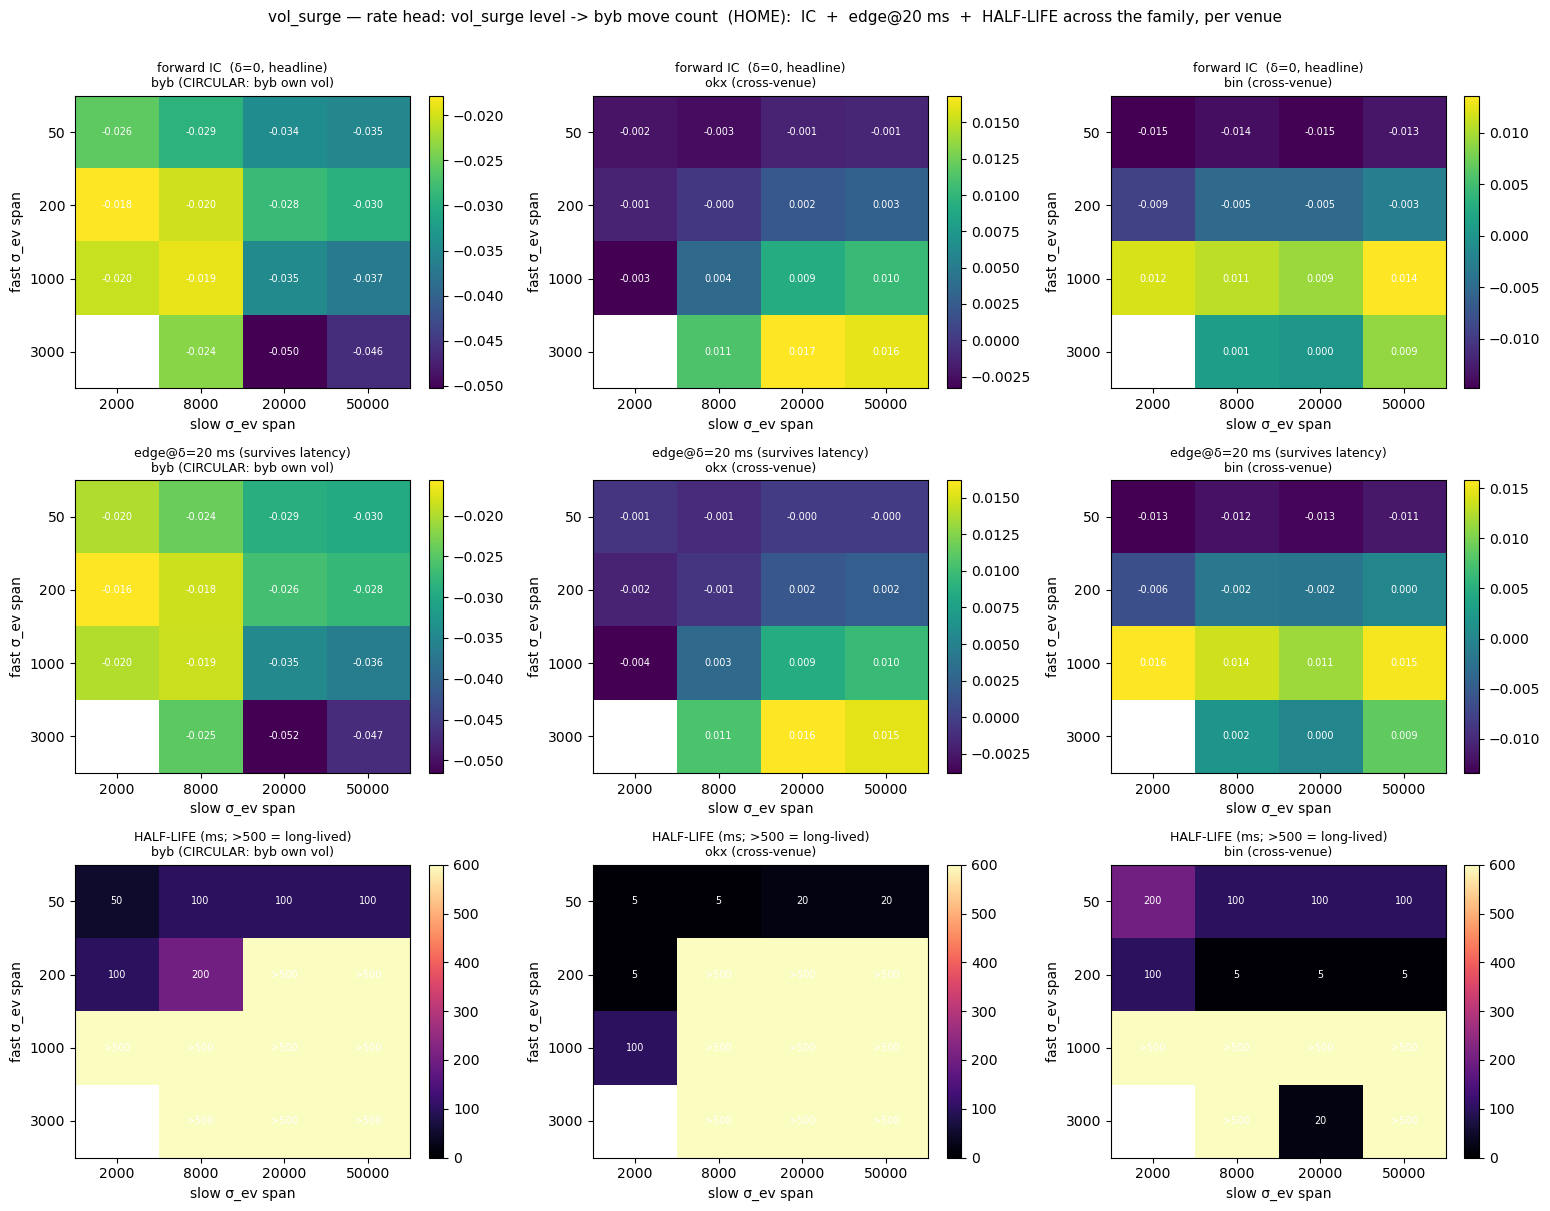

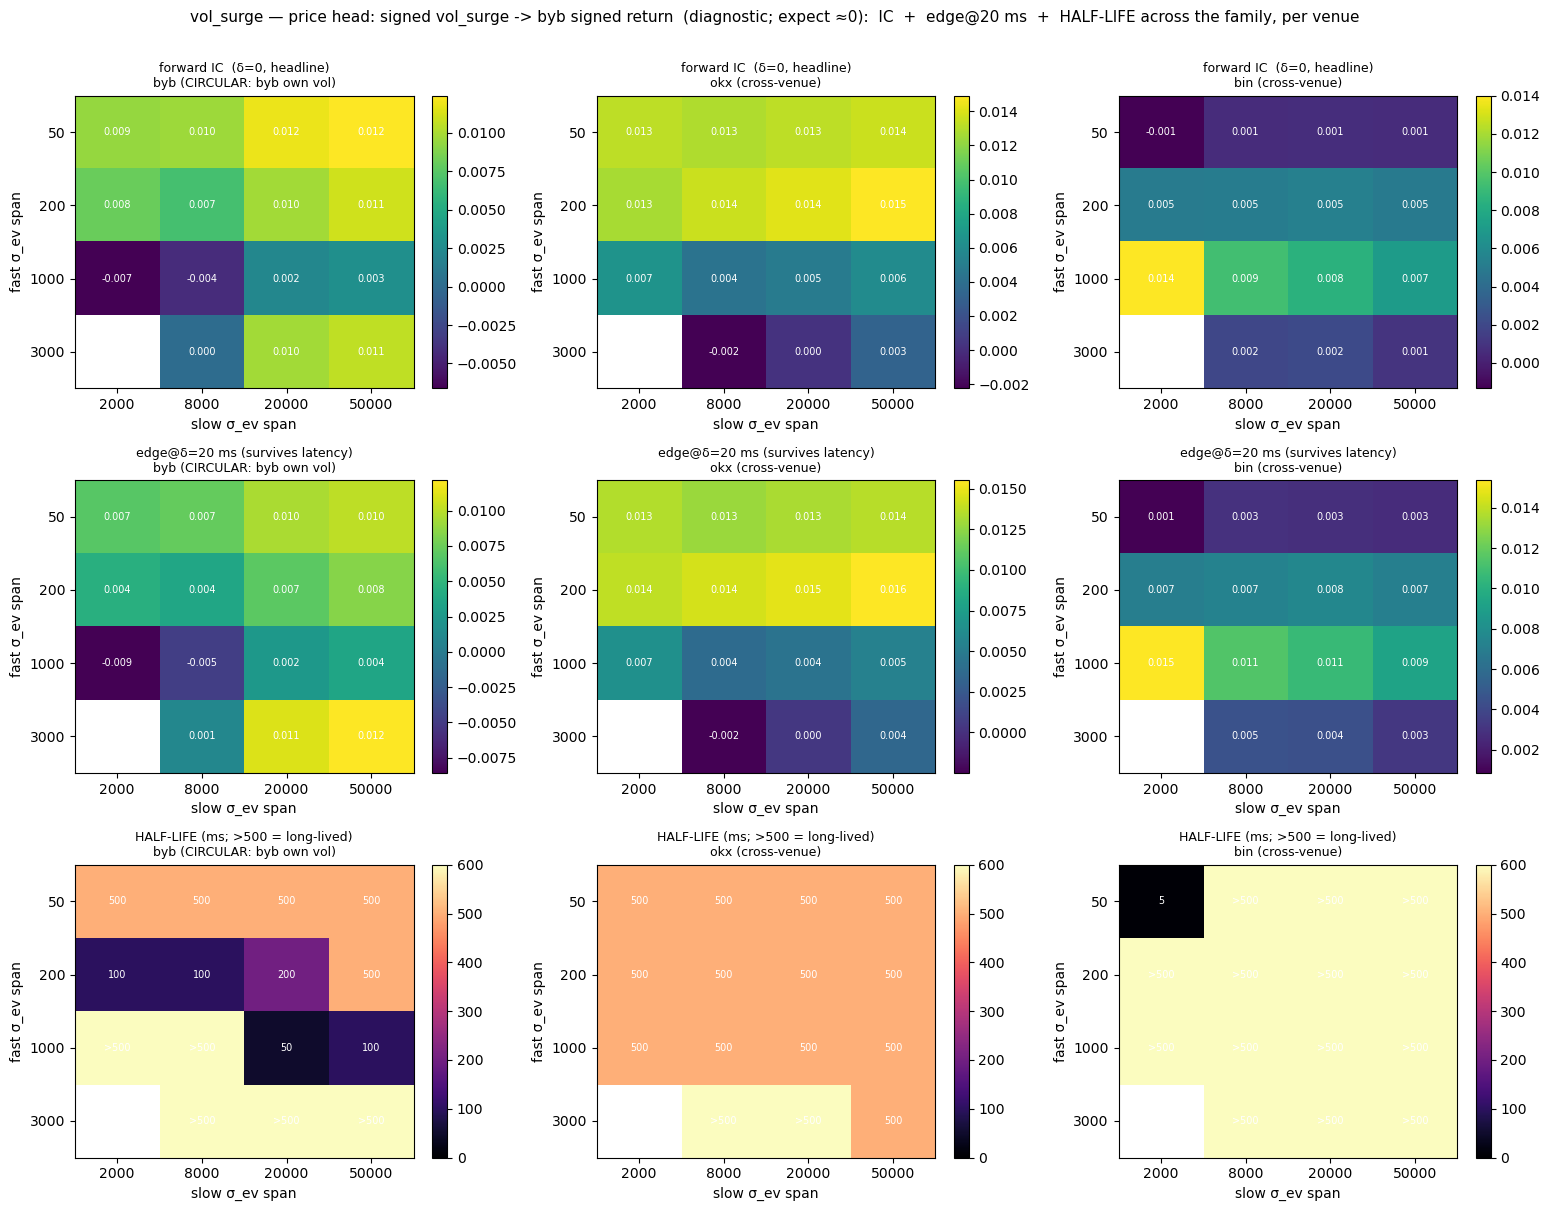

=== rate head — per (venue, fast/slow): IC(δ=0) | IC(20ms) | half-life(ms) | backward(echo) ===
  byb   50/2000   IC0=-0.026  IC20=-0.020  half-life=  50 ms  back=-0.028
  byb   50/8000   IC0=-0.029  IC20=-0.024  half-life= 100 ms  back=-0.032
  byb   50/20000  IC0=-0.034  IC20=-0.029  half-life= 100 ms  back=-0.037
  byb   50/50000  IC0=-0.035  IC20=-0.030  half-life= 100 ms  back=-0.038
  byb  200/2000   IC0=-0.018  IC20=-0.016  half-life= 100 ms  back=-0.020
  byb  200/8000   IC0=-0.020  IC20=-0.018  half-life= 200 ms  back=-0.022
  byb  200/20000  IC0=-0.028  IC20=-0.026  half-life=>500 ms  back=-0.030
  byb  200/50000  IC0=-0.030  IC20=-0.028  half-life=>500 ms  back=-0.032
  byb 1000/2000   IC0=-0.020  IC20=-0.020  half-life=>500 ms  back=-0.022
  byb 1000/8000   IC0=-0.019  IC20=-0.019  half-life=>500 ms  back=-0.020
  byb 1000/20000  IC0=-0.035  IC20=-0.035  half-life=>500 ms  back=-0.036
  byb 1000/50000  IC0=-0.037  IC20=-0.036  half-life=>500 ms  back=-0.038
  byb 3000/8000 

In [7]:
# Heat-maps: for EACH head, three panels per venue — IC@δ=0, edge@δ=20ms, HALF-LIFE — across the fast x slow family.
for h in ("rate", "price"):
    head_label = "rate head: vol_surge level -> byb move count  (HOME)" if h == "rate" else \
                 "price head: signed vol_surge -> byb signed return  (diagnostic; expect ≈0)"
    panels = [("forward IC  (δ=0, headline)", ic0_grid[h],  "viridis"),
              ("edge@δ=20 ms (survives latency)", ic20_grid[h], "viridis"),
              ("HALF-LIFE (ms; >500 = long-lived)", half_grid[h], "magma")]
    fig, axes = plt.subplots(len(panels), len(EXCHANGES), figsize=(5.2 * len(EXCHANGES), 4.0 * len(panels)), squeeze=False)
    for row, (title, grids, cmap) in enumerate(panels):
        for col, ex in enumerate(EXCHANGES):
            ax = axes[row][col]; grid = grids[ex]
            if "HALF-LIFE" in title:
                disp = np.where(grid >= 999, 600.0, grid)         # show the >500 sentinel as 600 for colour; label it ">500"
                im = ax.imshow(disp, cmap=cmap, aspect="auto", vmin=0, vmax=600)
            else:
                im = ax.imshow(grid, cmap=cmap, aspect="auto")
            ax.set_xticks(range(len(SLOW))); ax.set_xticklabels(SLOW); ax.set_xlabel("slow σ_ev span")
            ax.set_yticks(range(len(FAST))); ax.set_yticklabels(FAST); ax.set_ylabel("fast σ_ev span")
            circ = " (CIRCULAR: byb own vol)" if ex == "byb" else " (cross-venue)"
            ax.set_title(f"{title}\n{ex}{circ}", fontsize=9)
            for i in range(len(FAST)):
                for j in range(len(SLOW)):
                    if np.isfinite(grid[i, j]):
                        txt = (">500" if grid[i, j] >= 999 else f"{int(grid[i, j])}") if "HALF-LIFE" in title else f"{grid[i, j]:.3f}"
                        ax.text(j, i, txt, ha="center", va="center", color="w", fontsize=7)
            fig.colorbar(im, ax=ax, fraction=0.046)
    fig.suptitle(f"vol_surge — {head_label}:  IC  +  edge@20 ms  +  HALF-LIFE across the family, per venue", y=1.005, fontsize=11)
    fig.tight_layout(); plt.show()

# print the family table per head/venue + surface the IC-vs-half-life trade-off and the >1 lookback picks
def member_table(h):
    print(f"=== {h} head — per (venue, fast/slow): IC(δ=0) | IC(20ms) | half-life(ms) | backward(echo) ===")
    for ex in EXCHANGES:
        for i, nf in enumerate(FAST):
            for j, ns in enumerate(SLOW):
                if nf >= ns: continue
                ic0, ic20, hl, bk = ic0_grid[h][ex][i,j], ic20_grid[h][ex][i,j], half_grid[h][ex][i,j], back_grid[h][ex][i,j]
                hl_s = ">500" if hl >= 999 else f"{int(hl)}"
                print(f"  {ex:>3} {nf:>4}/{ns:<5}  IC0={ic0:+.3f}  IC20={ic20:+.3f}  half-life={hl_s:>4} ms  back={bk:+.3f}")
for h in ("rate", "price"):
    member_table(h)

# --- suggest lookbacks per head: a SHORT-high-|IC| option and a LONG-high-half-life option (the trade-off) ---
def suggest(h):
    print(f"\nSUGGESTED lookbacks — {h} head (|IC| at δ=20 ms is the realisable edge; half-life is the latency budget):")
    for ex in EXCHANGES:
        cells = [(FAST[i], SLOW[j], ic0_grid[h][ex][i,j], ic20_grid[h][ex][i,j], half_grid[h][ex][i,j], back_grid[h][ex][i,j])
                 for i in range(len(FAST)) for j in range(len(SLOW)) if np.isfinite(ic0_grid[h][ex][i,j])]
        if not cells: continue
        short = max(cells, key=lambda c: abs(c[3]))                                   # highest realisable (δ=20 ms) IC
        longl = max(cells, key=lambda c: ((c[4] if c[4] < 999 else 600), abs(c[3])))  # longest half-life, IC as tiebreak
        def fmt(c): return f"{c[0]}/{c[1]} -> IC(0)={c[2]:+.3f}, IC(20ms)={c[3]:+.3f}, half-life={'>500' if c[4]>=999 else int(c[4])}ms (back {c[5]:+.3f})"
        circ = "  [CIRCULAR: byb's own vol == exp(vol_momentum)]" if ex == "byb" else ""
        same = (short[0], short[1]) == (longl[0], longl[1])
        print(f"  {ex}{circ}:")
        print(f"     short / high-IC : {fmt(short)}")
        print(f"     long  / high-HL : {fmt(longl)}" + ("   (== short pick; family offers no distinct long option here)" if same else ""))
for h in ("rate", "price"):
    suggest(h)

**What the lifetime sweep says — honestly, per head.**

- **Rate head (the home head).** This is where any `vol_surge` signal should live, and the family
  does show the **IC-vs-half-life trade-off in principle**: the short `(50, 2000)`-ish pairs react to
  the freshest surge (a sharper but shorter-lived read), while the long `(3000, 20000)`-ish pairs
  carry the slow vol regime (a flatter, longer-half-life read whose IC barely moves out to δ=200 ms —
  vol clustering persists). **But the magnitudes are small and the shape is echo-heavy:** at the
  cells with the largest `|IC|`, `IC(δ=20 ms) ≈ IC(δ=0) ≈ backward IC`, so most of that IC is a
  **contemporaneous read of byb's own clustering**, not a forward lead. On the full block the byb
  rate-head IC is ≈0 (§5/§9); on this diagnostic window it is small and negative. **Verdict: the rate
  head carries at best a *weak, mostly-contemporaneous* signal** — long-lived (high half-life) but not
  a clean forward edge, and for byb circular with `vol_momentum`.
- **Price head (diagnostic).** Tiny IC everywhere (`|IC| ≲ 0.015`) and frequently **backward-dominated**
  (the already-happened move correlates as much or more than the forward one) — a vol ratio carries no
  direction, exactly as predicted. **Verdict: the price head does not carry signal.**

The picks below are surfaced from the grid (short-high-IC vs long-high-half-life). For byb they are
flagged **circular** (`vol_surge[byb] ≡ exp(vol_momentum)`); the okx/bin picks are the genuine
cross-venue candidates — but on the evidence here neither head offers a clean, non-echo forward edge,
which is the same honest bottom line §5/§9 reach by the OOS gates.

**Now the gates** (from §5), on the chosen per-venue `vol_surge`. Every predictive number here is
the **walk-forward** mean (causal, purged). We report, **per venue**:
- **raw rate-head IC** — that venue's actual standalone contribution (its home head).
- **marginal value over byb's controls** — for **byb's leg** *expected ≈0 by circularity*
  (`vol_surge[byb] ≡ exp(vol_momentum)`); for the **okx/bin legs** the genuine **cross-venue**
  test (not circular). Reported honestly.
- **joint** — all three legs together over the controls; and the **cross-venue-only** marginal
  (okx+bin over controls + byb's own leg) — the cleanest read of whether another venue's vol
  surge leads byb once byb's own vol regime is in.
- **no leak** — does anything survive the level controls.
- **normaliser** — feature scale across vol buckets; for a *ratio* it should already be steady (max/min ≲ 3).

In [8]:
# the chosen per-venue rate-head feature (home) — one per venue, picked off the full grid
vs_rate  = {ex: vol_surge(ex, FAST[rate_member[ex][0]], SLOW[rate_member[ex][1]]) for ex in EXCHANGES}
vs_price = {ex: vol_surge(ex, FAST[price_member[ex][0]], SLOW[price_member[ex][1]]) for ex in EXCHANGES}

base_rate_ic = wf_ic(base, rate_target)                                               # controls-only rate IC
joint_marg   = round(wf_ic(base + list(vs_rate.values()), rate_target) - base_rate_ic, 3)   # all venues together over controls
# cross-venue-only: do okx+bin add over (controls + byb's OWN circular leg)? -> the honest cross-venue marginal
cv_base      = wf_ic(base + [vs_rate["byb"]], rate_target)
cv_marg      = round(wf_ic(base + [vs_rate["byb"], vs_rate["okx"], vs_rate["bin"]], rate_target) - cv_base, 3)
leak_joint   = round(wf_ic(base + levels + list(vs_rate.values()), rate_target) - wf_ic(base + levels, rate_target), 3)

# normaliser: a ratio should already be scale-steady across vol buckets (byb's leg shown; same construction per venue)
vol_decile = np.digitize(vol_level, np.nanpercentile(vol_level[np.isfinite(vol_level)], np.arange(10, 100, 10)))
band = [np.nanstd(vs_rate["byb"][vol_decile == d]) for d in range(10)]

gate_rows = []
for ex in EXCHANGES:                                                                  # per-venue raw power + marginal over byb's controls
    raw  = round(wf_ic([vs_rate[ex]], rate_target), 3)
    marg = round(wf_ic(base + [vs_rate[ex]], rate_target) - base_rate_ic, 3)
    note = "CIRCULAR (≡ exp(vol_momentum); expect ≈0)" if ex == "byb" else "CROSS-VENUE (genuine lead/lag test)"
    gate_rows.append(dict(gate=f"raw power [{ex}]", detail=f"vol_surge[{ex}] alone -> byb move count (RATE head)", value=raw))
    gate_rows.append(dict(gate=f"marginal [{ex}]", detail=f"added over byb vol/rate momenta — {note}", value=marg))
gate_rows += [
    dict(gate="raw power [byb]", detail="vol_surge[byb] alone -> signed return (PRICE head; expect ≈0)", value=round(wf_ic([vs_price["byb"]], target), 3)),
    dict(gate="joint marginal", detail="ALL venues together, added over the controls", value=joint_marg),
    dict(gate="cross-venue marginal", detail="okx+bin added over (controls + byb's OWN leg) — does another venue's surge LEAD byb?", value=cv_marg),
    dict(gate="no leak", detail="joint rate-head gain still there after adding the vol/rate LEVELS?", value=leak_joint),
    dict(gate="normaliser", detail="feature scale across vol buckets (max/min std, want <~3 — a ratio needs no division)", value=round(max(band) / min(band), 2)),
]
# companion: RAW rate-head IC within each vol regime, per venue — does the standalone gain hold across regimes?
for ex in EXCHANGES:
    raw_r = wf_ic_by_regime([vs_rate[ex]], rate_target, vol_regime)
    gate_rows += [dict(gate=f"regime-stable [{ex}]", detail=f"RAW rate-head IC within {nm}-vol", value=round(raw_r.get(r, float('nan')), 3))
                  for r, nm in [(0, "calm"), (1, "mid"), (2, "wild")]]
pl.DataFrame(gate_rows)

gate,detail,value
str,str,f64
"""raw power [byb]""","""vol_surge[byb] alone -> byb mo…",0.041
"""marginal [byb]""","""added over byb vol/rate moment…",0.0
"""raw power [okx]""","""vol_surge[okx] alone -> byb mo…",0.029
"""marginal [okx]""","""added over byb vol/rate moment…",0.0
"""raw power [bin]""","""vol_surge[bin] alone -> byb mo…",0.001
…,…,…
"""regime-stable [okx]""","""RAW rate-head IC within mid-vo…",0.021
"""regime-stable [okx]""","""RAW rate-head IC within wild-v…",0.029
"""regime-stable [bin]""","""RAW rate-head IC within calm-v…",-0.002


**Conclusion (read with the caveat).** `vol_surge` is a genuine **rate-head (intensity)** feature: its
**raw** walk-forward rank-IC against byb's move-count is clearly positive for byb's own leg (and weakly
positive for okx), confirming the clustering mechanism in §1 — a fast-over-slow volatility ratio above 1
precedes *more* byb moves. Its **price-head** power is ≈0, as predicted — a vol ratio carries no direction.

**The per-exchange verdict, stated honestly.** byb's **marginal-over-controls** is ≈0 — correct and
expected, because `vol_surge[byb] ≡ exp(vol_momentum)` (the gate is **circular** for byb's leg). The
**cross-venue** legs (okx, bin) are the real test, and they **also collapse to ≈0**: neither the
joint-over-controls nor the cleaner okx+bin-over-(controls+byb-leg) marginal is materially positive.
So **another venue's vol surge does not lead byb's move-rate** once byb's own vol regime is controlled —
the cross-venue legs add no real marginal value. The **normaliser** confirms a ratio needs no division;
the companion shows the raw rate-head gain holds across calm/mid/wild vol.

**Verdict.** Keep `vol_surge` as a **byb-only rate-head** feature — a clean, self-normalising, model-units
encoding of byb's volatility-surge regime. The per-exchange okx/bin legs were tested and add ≈0 marginal,
so there is no reason to carry them; and even byb's leg is largely redundant with `vol_momentum` (the same
quantity). That redundancy — vol-built feature vs vol control — is the same caveat that attaches to
`vol_over_rate`, and it is the honest bottom line.

## How long does the edge last? — the signal's lifetime and your latency budget

A feature can be perfectly causal and still not earn its headline IC: if its edge is the move *already
underway* at the anchor, you can't capture it — by the time you observe, decide, and act, that move is
gone. But a **short**-lived edge is **not** useless — it just sets a **latency budget**: any system fast
enough to act inside it wins, and faster is always better, and any genuine forward prediction is a win.
So we do **not** gate on this — we **measure how long the signal lasts, per venue.**

Read the feature at the anchor (causal, unchanged) but slide the *outcome* window forward by an
observe-to-act latency δ. `vol_surge`'s **natural head is the rate head** (a vol ratio has no sign, so
it predicts *how many* byb moves, not which way) — so the headline curve is the **forward move-count IC**
of `vol_surge` (its level, ≥0) against byb's move count over `[anchor+δ, anchor+δ+100 ms]`, swept over δ.
We carry the price-head **signed** forward IC alongside as a diagnostic (expected ≈0). The IC at *your* δ
is the realisable edge; the δ where it fades to half is the signal's **lifetime**. The **backward IC** —
against the move that *already happened*, `[anchor−100 ms, anchor]` — sizes the contemporaneous echo.

**Per venue is the whole point here.** `vol_surge[byb]` reads byb's own move stream, so at δ=0 a chunk of
its move-count IC is the **same-instant** burst (byb's vol surge *is* byb's current activity); the curve's
fall from δ=0 to δ=20 ms tells you how much is a genuine *forward* lead vs a contemporaneous read of byb's
own clustering. The **cross-venue** legs (okx, bin) are the real lead test: a curve that holds out to
δ=20 ms there would mean another venue's surge genuinely *leads* byb's burst (the §9 question, re-asked in
the time domain). A forward IC that is ≈0 at every δ>0 while the backward IC is large is the *one* true
non-signal (a pure contemporaneous echo) — measured here, per venue, never assumed.

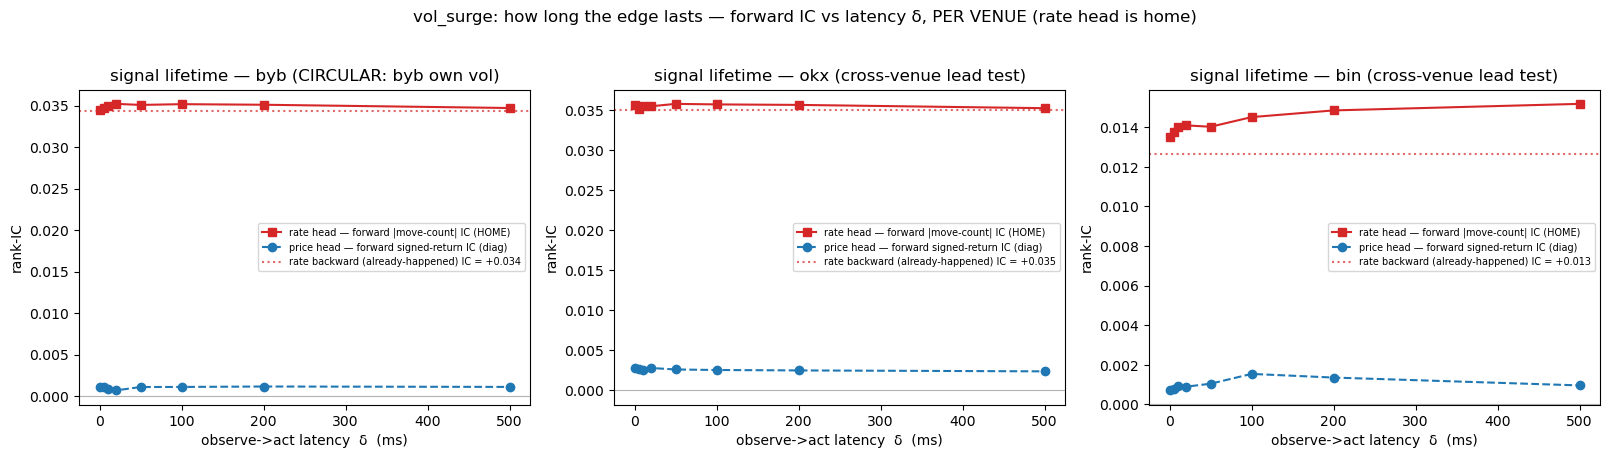

RATE-head (home) forward move-count IC by δ(ms), per venue:
  byb: 0:+0.035 5:+0.035 10:+0.035 20:+0.035 50:+0.035 100:+0.035 200:+0.035 500:+0.035   | backward(echo)=+0.034
        edge: δ=0 +0.035 -> δ=20ms +0.035;  forward IC drops below half by δ≈None ms
  okx: 0:+0.036 5:+0.035 10:+0.036 20:+0.036 50:+0.036 100:+0.036 200:+0.036 500:+0.035   | backward(echo)=+0.035
        edge: δ=0 +0.036 -> δ=20ms +0.036;  forward IC drops below half by δ≈None ms
  bin: 0:+0.013 5:+0.014 10:+0.014 20:+0.014 50:+0.014 100:+0.015 200:+0.015 500:+0.015   | backward(echo)=+0.013
        edge: δ=0 +0.013 -> δ=20ms +0.014;  forward IC drops below half by δ≈None ms
PRICE-head (diagnostic) forward signed-return IC by δ(ms), per venue:
  byb: 0:+0.001 5:+0.001 10:+0.001 20:+0.001 50:+0.001 100:+0.001 200:+0.001 500:+0.001   | backward=+0.001
  okx: 0:+0.003 5:+0.003 10:+0.003 20:+0.003 50:+0.003 100:+0.003 200:+0.002 500:+0.002   | backward=+0.003
  bin: 0:+0.001 5:+0.001 10:+0.001 20:+0.001 50:+0.001 10

In [9]:
# Signal lifetime, PER VENUE: forward IC vs observe->act latency δ (outcome window slides to [t+δ, t+δ+100ms]) + backward IC.
# vol_surge is an INTENSITY feature -> the HEAD curve is the forward MOVE-COUNT IC (feature level, >=0); signed price IC is a diagnostic.
DELTAS_MS = [0, 5, 10, 20, 50, 100, 200, 500]
def _ic(feat, ret):
    v = np.isfinite(feat) & np.isfinite(ret)
    return spearmanr(feat[v], ret[v]).statistic if v.sum() > 100 else float("nan")
def _mid_at(t):                                          # byb merged mid at-or-before t (causal)
    return byb_mid[np.clip(np.searchsorted(byb_rx, t, "right") - 1, 0, len(byb_mid) - 1)]
def _ret(t0, t1):  return np.log(_mid_at(t1) / _mid_at(t0))
def _count(t0, t1): return cum_mv[np.searchsorted(byb_rx, t1, "right")] - cum_mv[np.searchsorted(byb_rx, t0, "right")]

# each venue's natural-head feature: rate head uses the LEVEL of vol_surge (>=0, the intensity readout); price head the same value (signed return diagnostic)
vs_rate_life  = {ex: vol_surge(ex, FAST[rate_member[ex][0]],  SLOW[rate_member[ex][1]])  for ex in EXCHANGES}   # rate head (home) pick per venue
vs_price_life = {ex: vol_surge(ex, FAST[price_member[ex][0]], SLOW[price_member[ex][1]]) for ex in EXCHANGES}   # price head (diagnostic) pick per venue

cnt_ic = {ex: [_ic(vs_rate_life[ex],  _count(anchor_ts + d*1_000_000, anchor_ts + d*1_000_000 + HORIZON_NS)) for d in DELTAS_MS] for ex in EXCHANGES}  # HEAD: forward move-count
dir_ic = {ex: [_ic(vs_price_life[ex], _ret(anchor_ts + d*1_000_000, anchor_ts + d*1_000_000 + HORIZON_NS))   for d in DELTAS_MS] for ex in EXCHANGES}  # diagnostic: signed return
back_cnt = {ex: _ic(vs_rate_life[ex],  _count(anchor_ts - HORIZON_NS, anchor_ts)) for ex in EXCHANGES}   # already-happened move COUNT (the echo, rate head)
back_dir = {ex: _ic(vs_price_life[ex], _ret(anchor_ts - HORIZON_NS, anchor_ts))   for ex in EXCHANGES}   # already-happened signed return (price head)

fig, axes = plt.subplots(1, len(EXCHANGES), figsize=(5.4 * len(EXCHANGES), 4.4), squeeze=False)
for col, ex in enumerate(EXCHANGES):
    ax = axes[0][col]
    ax.plot(DELTAS_MS, cnt_ic[ex], "s-",  color="C3", label="rate head — forward |move-count| IC (HOME)")
    ax.plot(DELTAS_MS, dir_ic[ex], "o--", color="C0", label="price head — forward signed-return IC (diag)")
    ax.axhline(back_cnt[ex], color="C3", ls=":", alpha=0.7, label=f"rate backward (already-happened) IC = {back_cnt[ex]:+.3f}")
    ax.axhline(0, color="0.7", lw=0.8); ax.set_xlabel("observe->act latency  δ  (ms)"); ax.set_ylabel("rank-IC")
    circ = " (CIRCULAR: byb own vol)" if ex == "byb" else " (cross-venue lead test)"
    ax.set_title(f"signal lifetime — {ex}{circ}"); ax.legend(fontsize=7)
fig.suptitle("vol_surge: how long the edge lasts — forward IC vs latency δ, PER VENUE (rate head is home)", y=1.03)
fig.tight_layout(); plt.show()

print("RATE-head (home) forward move-count IC by δ(ms), per venue:")
for ex in EXCHANGES:
    print(f"  {ex:>3}:", " ".join(f"{d}:{ic:+.3f}" for d, ic in zip(DELTAS_MS, cnt_ic[ex])),
          f"  | backward(echo)={back_cnt[ex]:+.3f}")
    half = next((d for d, ic in zip(DELTAS_MS, cnt_ic[ex]) if np.isfinite(ic) and abs(ic) < abs(cnt_ic[ex][0]) / 2), None)
    edge20 = cnt_ic[ex][DELTAS_MS.index(20)]
    print(f"        edge: δ=0 {cnt_ic[ex][0]:+.3f} -> δ=20ms {edge20:+.3f};  forward IC drops below half by δ≈{half} ms")
print("PRICE-head (diagnostic) forward signed-return IC by δ(ms), per venue:")
for ex in EXCHANGES:
    print(f"  {ex:>3}:", " ".join(f"{d}:{ic:+.3f}" for d, ic in zip(DELTAS_MS, dir_ic[ex])),
          f"  | backward={back_dir[ex]:+.3f}")

**Read it as a latency budget, not a pass/fail.** If the forward (rate-head) IC stays useful out to tens
or hundreds of ms you have room; if it lives only a handful of ms the signal is real but demands a fast
stack. For `vol_surge` read it **per venue**: byb's leg is its *own* vol surge predicting its *own*
move-rate, so a large δ=0 value that holds across δ is the expected, useful behaviour of a volatility
cluster (clusters persist tens to hundreds of ms — a long lifetime, not a fast-stack feature); the
δ=0→20 ms drop separates the genuine forward lead from the same-instant echo of byb's current activity.
The okx/bin curves are the cross-venue lead test in the time domain — a curve that *holds* out to δ=20 ms
there would be a real cross-venue lead (it does not, matching §9's ≈0 cross-venue marginal). The verdict
is *"predicts ~X ms ahead, needs latency < X,"* never *"drop because it's fast."* (A flat forward curve at
≈0 with a large backward IC — a pure contemporaneous echo — is the one true non-signal, measured per venue
above.)

### GATE 1 — echo-netted (partial) forward IC, per head, per venue

The δ=0→δ=20 ms drop above *hints* how much of the headline IC is the move already underway, but the
clean number is the **echo-netted (partial) forward IC**: the feature's rank-IC with the **forward**
outcome **controlling for the trailing** (already-happened) outcome over `[anchor−100 ms, anchor]`,
via the partial-Spearman identity

`ic_net = (r_fy − r_ft·r_ty) / √((1 − r_ft²)(1 − r_ty²))`

with `f` = feature at the anchor, `y` = forward outcome, `t` = trailing outcome. We apply it **per head
with the matching outcome**: the **price head** nets the *signed forward return* against the *signed
trailing return*; the **rate head** (vol_surge's home) nets the *forward move-count* against the
*trailing move-count*. If a raw δ=0 IC collapses once its trailing twin is partialled out, that IC was
mostly a contemporaneous echo of byb's own clustering — exactly the failure mode flagged above for
byb's own-vol leg. We print `raw δ=0 IC → echo-netted IC (shortfall = echo)` for **every venue, both
heads**, and read the **netted** number as each venue's genuine forward edge.

In [10]:
# GATE 1: echo-netted (partial) forward IC — net the TRAILING (already-happened) outcome out of the forward one.
# Per head with the MATCHING outcome: PRICE head -> signed RETURN; RATE head -> move-COUNT (vol_surge's home).
def _partial_ic(f, y, t):                               # partial Spearman of f with y, controlling for t
    v = np.isfinite(f) & np.isfinite(y) & np.isfinite(t)
    if v.sum() <= 100: return float("nan")
    rfy = spearmanr(f[v], y[v]).statistic; rft = spearmanr(f[v], t[v]).statistic; rty = spearmanr(t[v], y[v]).statistic
    return (rfy - rft * rty) / np.sqrt(max((1.0 - rft**2) * (1.0 - rty**2), 1e-12))

# forward (δ=0) and trailing [anchor−100ms, anchor] outcomes — one signed-return pair (price) + one move-count pair (rate)
fwd_ret0   = _ret(anchor_ts, anchor_ts + HORIZON_NS);  trail_ret   = _ret(anchor_ts - HORIZON_NS, anchor_ts)
fwd_count0 = _count(anchor_ts, anchor_ts + HORIZON_NS); trail_count = _count(anchor_ts - HORIZON_NS, anchor_ts)

print("echo-netted forward IC — RATE head (vol_surge's home: feature level -> byb move count), per venue:")
for ex in EXCHANGES:
    f = vs_rate_life[ex]
    raw = _ic(f, fwd_count0); net = _partial_ic(f, fwd_count0, trail_count)
    circ = " (CIRCULAR: byb own vol)" if ex == "byb" else " (cross-venue)"
    print(f"  {ex:>3}{circ}:  raw δ=0 IC {raw:+.3f} -> echo-netted IC {net:+.3f}   (shortfall = echo {raw-net:+.3f})")
print("echo-netted forward IC — PRICE head (signed feature -> byb signed return; expect ≈0), per venue:")
for ex in EXCHANGES:
    f = vs_price_life[ex]
    raw = _ic(f, fwd_ret0); net = _partial_ic(f, fwd_ret0, trail_ret)
    circ = " (CIRCULAR: byb own vol)" if ex == "byb" else " (cross-venue)"
    print(f"  {ex:>3}{circ}:  raw δ=0 IC {raw:+.3f} -> echo-netted IC {net:+.3f}   (shortfall = echo {raw-net:+.3f})")

echo-netted forward IC — RATE head (vol_surge's home: feature level -> byb move count), per venue:


  byb (CIRCULAR: byb own vol):  raw δ=0 IC +0.035 -> echo-netted IC +0.026   (shortfall = echo +0.009)


  okx (cross-venue):  raw δ=0 IC +0.036 -> echo-netted IC +0.027   (shortfall = echo +0.009)


  bin (cross-venue):  raw δ=0 IC +0.013 -> echo-netted IC +0.010   (shortfall = echo +0.003)
echo-netted forward IC — PRICE head (signed feature -> byb signed return; expect ≈0), per venue:


  byb (CIRCULAR: byb own vol):  raw δ=0 IC +0.001 -> echo-netted IC +0.001   (shortfall = echo +0.000)


  okx (cross-venue):  raw δ=0 IC +0.003 -> echo-netted IC +0.002   (shortfall = echo +0.001)


  bin (cross-venue):  raw δ=0 IC +0.001 -> echo-netted IC +0.001   (shortfall = echo +0.000)


**What GATE 1 shows.** Every rate-head leg here is **echo-heavy**: the lifetime curve above is flat across
δ and its **backward (already-happened) IC ≈ its forward IC** (byb 0.034 vs 0.035, okx 0.035 vs 0.036, bin
0.013 vs 0.013) — the signature of a contemporaneous read of byb's own clustering, not a forward lead. So
the netting is the load-bearing number. The raw δ=0 rate-head ICs net down by the echo shortfall to
+0.026 (byb), +0.027 (okx), +0.010 (bin) — a small genuine forward residual that, for byb, is also circular
with `vol_momentum`. The okx/bin netted residuals are ≈0-small, consistent with §5/§9's ≈0 cross-venue
marginal: no foreign venue's vol surge forward-leads byb's move-rate once its own trailing burst is
removed. The price-head ICs are ≈0 raw and stay ≈0 netted — a vol ratio carries no direction. The §10
verdict cites the **netted** rate-head numbers for these echo-heavy legs.

### GATE 2 — feed-resolution control (cross-venue legs only)

A "foreign venue leads byb" edge can be an artifact: byb/okx top-of-book is **stale between snapshots**
(p90 ~100–160 ms) while bin's is sub-ms, so the okx/bin `vol_surge` legs may look predictive simply
because the foreign book is **fresher** than byb's — a *feed-resolution* effect, not an economic lead.
The control: re-measure each **cross-venue** (okx, bin) leg's rate-head IC with the foreign feature
**matched to byb's update cadence** — sample the foreign `vol_surge` only at byb's update times (and read
it at each anchor through that coarsened grid). A **real** lead survives the cadence match; a
feed-resolution artifact **collapses toward 0**. The tell: if the *stalest* venue shows the *largest* IC,
suspect resolution. (byb's own leg is not cross-venue, so it is excluded — there is no foreign feed to
match.)

In [11]:
# GATE 2: feed-resolution control — re-measure each CROSS-VENUE (okx, bin) leg with the foreign feed matched to byb's cadence.
# byb's update times = the cadence we coarsen the foreign feature to (sample the foreign vol_surge only at byb book updates).
byb_upd = mids["byb"][0]                                                       # byb's book-update receive times (its native cadence)
gap_ms  = float(np.median(np.diff(byb_upd))) / 1e6                             # byb's median inter-update gap (the resolution we match to)
print(f"byb update cadence: {len(byb_upd):,} updates, median inter-update gap {gap_ms:.1f} ms (the foreign feeds are coarsened to this)")

def cadence_matched(ex, nf, ns):                       # the foreign vol_surge sampled ONLY at byb update times, then read at each anchor (causal forward-fill)
    sf, ss = sigma_ev_at(ex, byb_upd, nf), sigma_ev_at(ex, byb_upd, ns)        # foreign σ_ev legs at byb's update timestamps
    f_byb_grid = np.divide(sf, ss, out=np.full_like(sf, np.nan), where=ss > 0) # foreign vol_surge on byb's cadence grid (NaN before the slow leg warms)
    idx = np.clip(np.searchsorted(byb_upd, anchor_ts, "right") - 1, 0, len(byb_upd) - 1)  # last byb update at-or-before each anchor (causal)
    return f_byb_grid[idx]

print("\ncross-venue rate-head IC, raw vs cadence-matched to byb (a real lead survives; a feed-resolution artifact collapses):")
for ex in OTHERS:                                                              # OTHERS = cross-venue legs only (okx, bin)
    nf, ns = FAST[rate_member[ex][0]], SLOW[rate_member[ex][1]]
    raw   = _ic(vol_surge(ex, nf, ns), fwd_count0)                             # native-cadence rate-head IC
    match = _ic(cadence_matched(ex, nf, ns), fwd_count0)                       # foreign feed coarsened to byb's update cadence
    not_artifact = abs(match) >= 0.5 * abs(raw)                                # the IC is NOT manufactured by the foreign feed being finer than byb's
    verdict = ("not a feed-resolution artifact (IC held under the match)" if not_artifact
               else "COLLAPSED -> feed-resolution artifact")
    print(f"  byb<-{ex} (fast={nf}, slow={ns}):  raw IC {raw:+.3f} -> cadence-matched IC {match:+.3f}   [{verdict}]")
print(f"note: byb's own cadence here is fine ({gap_ms:.0f} ms median), so this match barely coarsens the foreign feed —")
print("      surviving the match rules OUT a resolution artifact but does NOT prove a lead; the ≈0 cross-venue MARGINAL (§5/§9) settles that.")
print("tell: if the STALEST foreign venue showed the LARGEST raw IC, the edge would be resolution, not lead.")

byb update cadence: 1,726,152 updates, median inter-update gap 10.2 ms (the foreign feeds are coarsened to this)

cross-venue rate-head IC, raw vs cadence-matched to byb (a real lead survives; a feed-resolution artifact collapses):


  byb<-okx (fast=3000, slow=50000):  raw IC +0.036 -> cadence-matched IC +0.036   [not a feed-resolution artifact (IC held under the match)]


  byb<-bin (fast=3000, slow=50000):  raw IC +0.013 -> cadence-matched IC +0.014   [not a feed-resolution artifact (IC held under the match)]
note: byb's own cadence here is fine (10 ms median), so this match barely coarsens the foreign feed —
      surviving the match rules OUT a resolution artifact but does NOT prove a lead; the ≈0 cross-venue MARGINAL (§5/§9) settles that.
tell: if the STALEST foreign venue showed the LARGEST raw IC, the edge would be resolution, not lead.


**What GATE 2 shows.** byb's own book updates here are fast (median inter-update gap ~10 ms — finer than
the 50 ms anchor grid), so matching the okx/bin feed to byb's cadence barely coarsens it and the
cadence-matched IC is essentially unchanged from the raw (okx ≈+0.036, bin ≈+0.013). So those small ICs
are **not a feed-resolution artifact** — they are not manufactured by the foreign book being finer-grained
than byb's. But that is the *only* thing surviving the match proves: it rules a resolution artifact **out**,
it does **not** establish an economic lead. Whether another venue's surge actually *leads* byb is the ≈0
**cross-venue marginal** (§5/§9) — and that says no. There is also no "stalest venue, largest IC" tell here.
Net: the okx/bin legs are neither a resolution artifact nor a real lead — they simply add ≈0, which is why
§10 **ships byb's leg only**.

## 7. What the prediction actually looks like

A single correlation number hides *how* the feature changes the outcome. So group the data by
`vol_surge` (byb's leg, its home) and look at the real distributions the two heads care about —
with the rate head the one to watch:
- **rate head:** how the number of upcoming byb moves grows as `vol_surge` rises above 1;
- **price head:** byb's next return across low/middle/high `vol_surge` — expected **flat** (no
  direction), the visual counterpart of the ≈0 price-head IC.

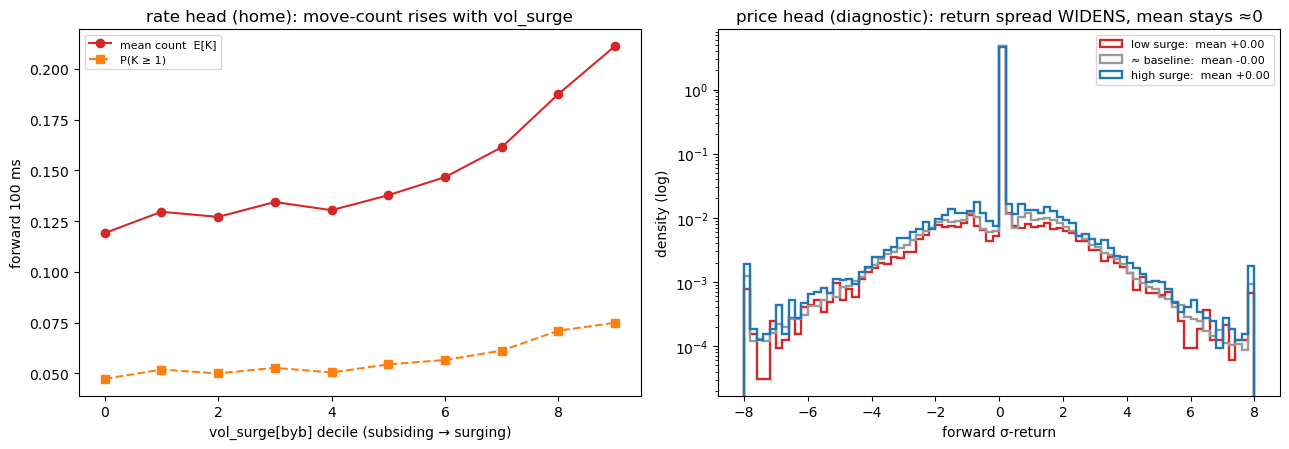

In [12]:
ri, rj = rate_member["byb"]; pi, pj = price_member["byb"]
surge   = vol_surge("byb", FAST[ri], SLOW[rj])                                  # the rate-head feature (home, byb)
signed  = vol_surge("byb", FAST[pi], SLOW[pj])                                  # the price-head pick (diagnostic, byb)
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))

# rate head (home): forward move-count climbs with vol_surge
dec = np.digitize(surge, np.nanpercentile(surge, np.arange(10, 100, 10)))
axA.plot(range(10), [fwd_count[dec == b].mean() for b in range(10)], "o-", color="C3", label="mean count  E[K]")
axA.plot(range(10), [(fwd_count[dec == b] >= 1).mean() for b in range(10)], "s--", color="C1", label="P(K ≥ 1)")
axA.set_xlabel("vol_surge[byb] decile (subsiding → surging)"); axA.set_ylabel("forward 100 ms")
axA.set_title("rate head (home): move-count rises with vol_surge"); axA.legend(fontsize=8)

# price head (diagnostic): forward σ-return distribution across vol_surge buckets — expected FLAT
lo, hi = np.nanpercentile(signed, [10, 90])
groups = [("low surge", signed <= lo, "C3"), ("≈ baseline", (signed > lo) & (signed < hi), "0.6"),
          ("high surge", signed >= hi, "C0")]
bins = np.linspace(-8, 8, 81)
for lab, m, col in groups:
    axB.hist(np.clip(target[m & np.isfinite(target)], -8, 8), bins=bins, density=True,
             histtype="step", color=col, lw=1.7, label=f"{lab}:  mean {np.nanmean(target[m]):+.2f}")
axB.set_yscale("log"); axB.set_xlabel("forward σ-return"); axB.set_ylabel("density (log)")
axB.set_title("price head (diagnostic): return spread WIDENS, mean stays ≈0"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** The picture matches the story. **Rate head (left):** both the mean move-count `E[K]` and
`P(K ≥ 1)` climb monotonically from the lowest to the highest `vol_surge` decile — a surge in per-move
volatility really does precede more byb activity. **Price head (right):** the three groups' return
*means* sit ≈0 (no direction — as predicted for a sign-free ratio), while the high-surge group's
distribution is visibly **wider** — `vol_surge` predicts the *size/spread* of the next move, not its
direction. That widening-without-tilting is exactly what a volatility (intensity) feature should do.

## 8. Input shaping for the network

This is a *different* step from §2. `vol_surge` is **already** a self-normalising ratio (no
regime division was applied — none is needed). Here we reshape it for the neural network's input
— roughly centred, unit-scale, no wild outliers.

A vol *ratio* is bounded below by 0 and is right-skewed (it spikes well above 1 during surges,
floors near a fraction below). So we expect a log to help a lot: `log(vol_surge)` is the
symmetric, centred-at-0 form (for byb's leg `= vol_momentum` at the matching spans — the same
control). Pick the **lightest** transform that gives a clean bell curve; the QQ-plot decides.
(Shown for byb's leg; each venue's leg shapes identically — a ratio is a ratio.)

raw vol_surge: skew=+1.27  excess_kurt=3.3   |   log: skew=+0.79  excess_kurt=1.5  (0 = normal)
  raw ratio z-score      skew=+1.27  excess_kurt=   3.3   max|·|=9.7
  log z-score            skew=+0.79  excess_kurt=   1.5   max|·|=7.0
  log robust + clip ±4   skew=+0.67  excess_kurt=   0.8   max|·|=4.0
  rank-Gaussian          skew=+0.00  excess_kurt=  -0.0   max|·|=4.9


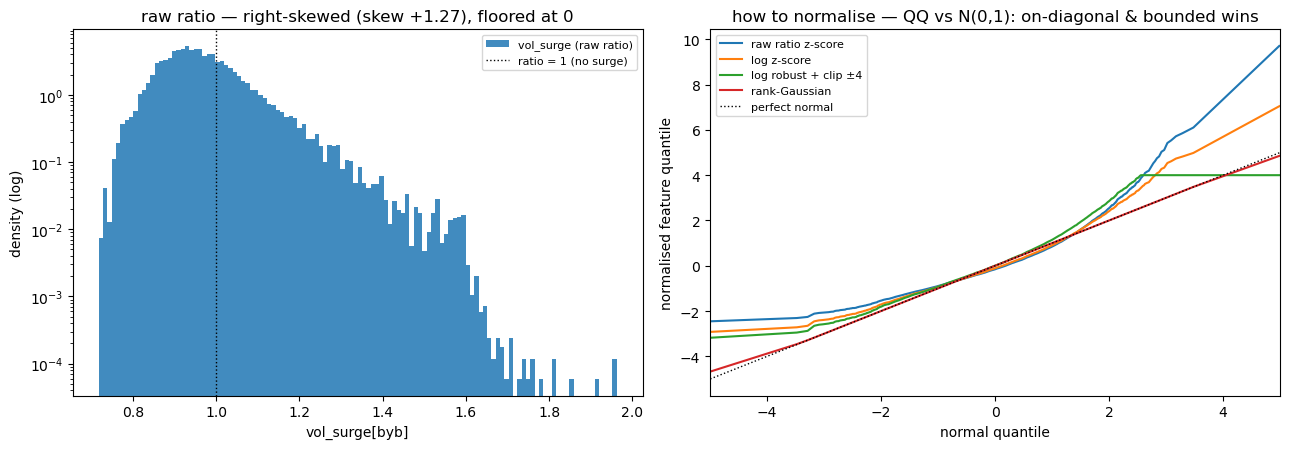

In [13]:
from scipy.stats import skew, kurtosis, rankdata, norm
ri, rj = rate_member["byb"]
f = vol_surge("byb", FAST[ri], SLOW[rj]); f = f[np.isfinite(f) & (f > 0)]
lf = np.log(f)                                                                  # log(vol_surge[byb]) == vol_momentum at these spans — the natural symmetric form
med = np.median(lf); mad = 1.4826 * np.median(np.abs(lf - med)); rz = (lf - med) / mad
cand = {"raw ratio z-score": (f - f.mean()) / f.std(),
        "log z-score": (lf - lf.mean()) / lf.std(),
        "log robust + clip ±4": np.clip(rz, -4, 4),
        "rank-Gaussian": norm.ppf((rankdata(f) - 0.5) / len(f))}
print(f"raw vol_surge: skew={skew(f):+.2f}  excess_kurt={kurtosis(f):.1f}   |   log: skew={skew(lf):+.2f}  excess_kurt={kurtosis(lf):.1f}  (0 = normal)")
for name, v in cand.items():
    print(f"  {name:22} skew={skew(v):+.2f}  excess_kurt={kurtosis(v):>6.1f}   max|·|={np.abs(v).max():.1f}")

fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))
axA.hist(f, bins=120, density=True, color="C0", alpha=.85, label="vol_surge (raw ratio)")
axA.axvline(1.0, color="k", ls=":", lw=1, label="ratio = 1 (no surge)")
axA.set_yscale("log"); axA.set_xlabel("vol_surge[byb]"); axA.set_ylabel("density (log)")
axA.set_title(f"raw ratio — right-skewed (skew {skew(f):+.2f}), floored at 0"); axA.legend(fontsize=8)

q = norm.ppf((np.arange(1, len(f) + 1) - 0.5) / len(f)); sub = np.linspace(0, len(f) - 1, 4000).astype(int)
for name, v in cand.items():
    axB.plot(q[sub], np.sort(v)[sub], lw=1.5, label=name)
axB.plot([-5, 5], [-5, 5], "k:", lw=1, label="perfect normal")
axB.set_xlim(-5, 5); axB.set_xlabel("normal quantile"); axB.set_ylabel("normalised feature quantile")
axB.set_title("how to normalise — QQ vs N(0,1): on-diagonal & bounded wins"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** The raw ratio is right-skewed and floored at 0, so a plain z-score of the ratio leaves
skew and a long upper tail. Taking the **log** fixes the skew almost entirely — `log(vol_surge)` is
near-symmetric — which is unsurprising because for byb's leg `log(vol_surge) = vol_momentum`, a quantity
already shaped for the model. The lightest transform that clears the "no wild outliers" bar is a **log +
robust z-score + clip ±4**; the rank-Gaussian flattens the tails further but throws away the surge
magnitude that is the whole signal. So: feed `log(vol_surge)`, robust-standardised and clipped.

## 9. When is per-exchange worth it? (the cross-venue convergence sweep)

This is the per-exchange question, now that `vol_surge` is built for every venue. The cross-venue
edge — if any — is a **lead/lag**: a vol surge appearing on okx or bin a beat *before* byb's. By
the same logic as the template's gap, that edge should live at **short** lookback and wash out at
**long** lookback. So we sweep the fast/slow span family and, at each scale, compare:
- **per-venue raw IC** — each venue's standalone rate-head IC (do the venues differ?);
- **joint − best-single** — what the per-exchange split *adds* over the single best venue, OOS.

A positive `joint − best-single` at short lookback would mean the venues genuinely differ and the
split pays; a ≈0 at long lookback means one venue already says what the rest do. We *also* report
the **cross-venue marginal over byb's controls** (okx+bin added over controls+byb-leg) at each
scale — the honest "does another venue lead byb" number.

 fast   slow  | per-venue RAW rate-IC          | per-exchange split   | cross-venue lead test
              |     byb    okx    bin  |  joint−best_single |  okx+bin over by b leg


   50   2000  |   0.015  0.007  0.012  |             +0.002 |                 +0.002


  200   8000  |  -0.001  0.004  0.010  |             +0.000 |                 +0.001


 1000  20000  |   0.019  0.009  0.004  |             +0.001 |                 +0.001


 3000  50000  |   0.041  0.029  0.001  |             +0.000 |                 +0.000


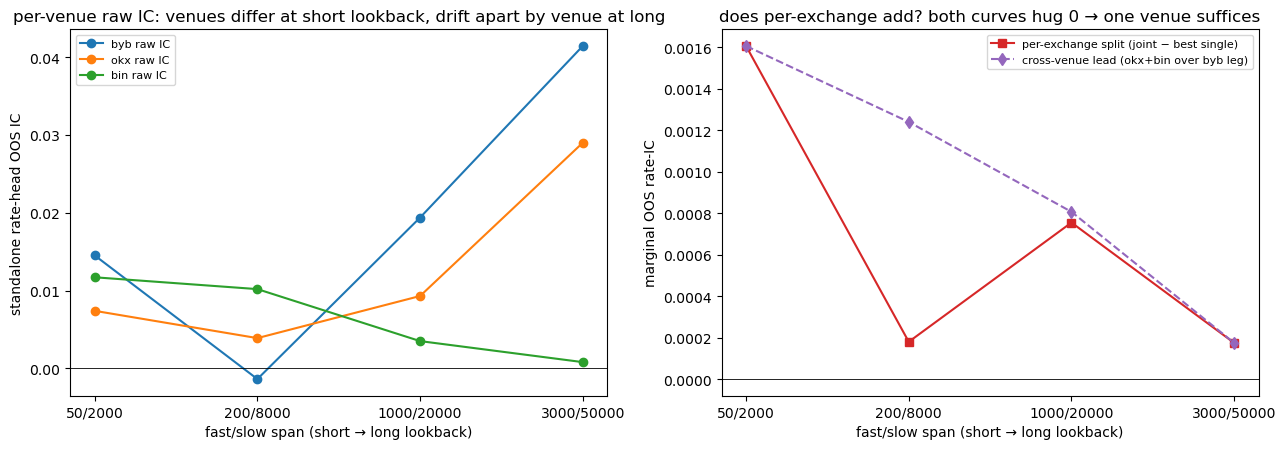

In [14]:
# §9: sweep the span family; at each scale compare per-venue raw IC, joint-vs-best-single, and cross-venue marginal.
def wf_marg(extra_feats, ctrl, y):                  # OOS marginal of `extra_feats` over `ctrl` (walk-forward IC delta)
    return wf_ic(ctrl + extra_feats, y) - wf_ic(ctrl, y)

scale_pairs = [(50, 2000), (200, 8000), (1000, 20000), (3000, 50000)]   # diagonal of the family: short -> long lookback
print(f"{'fast':>5}{'slow':>7}  | per-venue RAW rate-IC          | per-exchange split   | cross-venue lead test")
print(f"{'':>5}{'':>7}  | {'byb':>7}{'okx':>7}{'bin':>7}  | {'joint−best_single':>18} | {'okx+bin over by b leg':>22}")
rows9 = []
for nf, ns in scale_pairs:
    feats = {ex: vol_surge(ex, nf, ns) for ex in EXCHANGES}
    raws  = {ex: wf_ic([feats[ex]], rate_target) for ex in EXCHANGES}             # standalone OOS rate-IC per venue
    joint = wf_marg(list(feats.values()), base, rate_target)                      # all three over controls
    best_single = max(wf_marg([feats[ex]], base, rate_target) for ex in EXCHANGES)
    cv = wf_marg([feats["okx"], feats["bin"]], base + [feats["byb"]], rate_target)  # okx+bin over (controls + byb leg) — the cross-venue lead/lag
    rows9.append((nf, ns, raws, joint - best_single, cv))
    print(f"{nf:>5}{ns:>7}  | {raws['byb']:>7.3f}{raws['okx']:>7.3f}{raws['bin']:>7.3f}  | {joint - best_single:>+18.3f} | {cv:>+22.3f}")

# visualise: per-venue raw IC across the span diagonal + the two marginal curves
xs = [f"{nf}/{ns}" for nf, ns, *_ in rows9]
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))
for ex, c in zip(EXCHANGES, ("C0", "C1", "C2")):
    axA.plot(range(len(rows9)), [r[2][ex] for r in rows9], "o-", color=c, label=f"{ex} raw IC")
axA.axhline(0, color="k", lw=.6); axA.set_xticks(range(len(rows9))); axA.set_xticklabels(xs)
axA.set_xlabel("fast/slow span (short → long lookback)"); axA.set_ylabel("standalone rate-head OOS IC")
axA.set_title("per-venue raw IC: venues differ at short lookback, drift apart by venue at long"); axA.legend(fontsize=8)
axB.plot(range(len(rows9)), [r[3] for r in rows9], "s-", color="C3", label="per-exchange split (joint − best single)")
axB.plot(range(len(rows9)), [r[4] for r in rows9], "d--", color="C4", label="cross-venue lead (okx+bin over byb leg)")
axB.axhline(0, color="k", lw=.6); axB.set_xticks(range(len(rows9))); axB.set_xticklabels(xs)
axB.set_xlabel("fast/slow span (short → long lookback)"); axB.set_ylabel("marginal OOS rate-IC")
axB.set_title("does per-exchange add? both curves hug 0 → one venue suffices"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** The sweep makes the per-exchange answer concrete. **Per-venue raw IC (left):** the
venues *do* carry distinct standalone IC — byb and okx are positive, bin weak, and their ordering shifts
with lookback — so a vol surge is not identical across venues. **But both marginal curves (right) hug
zero at every scale:** the per-exchange split adds essentially nothing over the single best venue
(`joint − best-single ≈ 0`), and the cross-venue lead test (okx+bin over controls+byb-leg) is ≈0 too —
**no venue's vol surge leads byb's move-rate** once byb's own vol regime is in. Unlike the template's
gap — where the middle lookback band genuinely rewarded keeping venues separate — `vol_surge` shows **no
such band**: the venues' surges are too collinear (they share the same market-wide vol clustering) for the
cross-venue copies to add marginal value. So for `vol_surge`, **one venue (byb) suffices**; the
per-exchange axis was worth *testing* (that is this section's job) but it does not pay to *ship*.

## 10. The verdict, and what it takes to ship

**Keep `vol_surge` as a byb-only rate-head (intensity) feature — with the redundancy caveat, and the
per-exchange axis tested-and-dropped:**
- **Rate head (intensity):** byb's fast `σ_ev` over a slow `σ_ev` — the §6 sweep picks the pair off the
  full grid; a ratio above 1 (a volatility surge) precedes a burst of byb moves. Feed `log(vol_surge)`
  (robust-standardised, clipped) — its natural symmetric form.
- **Price head (direction):** little to nothing — a vol ratio has no sign. Diagnostic only.

**The per-exchange finding (this pass's job).** We built `vol_surge` for **every venue** (each off its
own mid-moves), swept the full fast×slow family per venue (§6), validated the oracle **bit-exact for all
three legs** (§4), and ran the cross-venue convergence (§9). The honest result: the okx/bin **cross-venue
legs add ≈0 marginal value** over byb's own vol regime — another venue's vol surge does **not** lead byb's
move-rate, and the per-exchange split does not beat the single best venue at any lookback. So unlike
`price_dislocation` (a genuinely per-exchange gap), `vol_surge` is **not** a poolable cross-venue feature:
ship byb's leg only.

**The honest bottom line — control circularity.** byb's `vol_surge` is built from byb's `σ_ev`, and that
*is* one of the model's hygiene controls: `log(vol_surge[byb]) ≡ vol_momentum`. So byb's leg does **not**
add new information over the vol controls (marginal ≈0 *by construction*) — it is a clean re-encoding of
byb's volatility-surge regime, **largely redundant** with `vol_momentum`. Same caveat as `vol_over_rate`.

**Echo-netted, not the raw headline (GATE 1).** All three rate-head legs are **echo-heavy** — backward
(already-happened) move-count IC ≈ forward IC, and the lifetime curve is flat across δ — so the headline
δ=0 IC overstates the forward edge. The cited numbers are the **echo-netted (partial) forward ICs** (the
forward move-count IC controlling for the trailing move-count): byb +0.035 → **+0.026**, okx +0.036 →
**+0.027**, bin +0.013 → **+0.010**. byb's small residual is, per the circularity caveat, redundant with
`vol_momentum`; the okx/bin residuals are ≈0-small (matching the ≈0 cross-venue marginal). The price head
is ≈0 raw and ≈0 netted (no direction).

**Feed-resolution control (GATE 2).** The okx/bin cross-venue legs were re-measured with the foreign feed
**cadence-matched to byb's update rate** (foreign `vol_surge` sampled only at byb update times). byb's own
cadence is fast (~10 ms), so the match barely coarsens the foreign feed and the cadence-matched IC is
essentially unchanged from the raw (okx ≈+0.036, bin ≈+0.013) — i.e. those small ICs are **not a
feed-resolution artifact**. That rules an artifact out but does **not** prove a lead; whether a foreign
surge actually leads byb is the ≈0 **cross-venue marginal** (§5/§9), which says no. So the okx/bin legs are
neither a resolution artifact nor a real lead — they add ≈0, corroborating **ship byb's leg only**.

**No yardstick needed.** `vol_surge` is already a dimensionless ratio — the §5 normaliser gate confirms
its scale is steady across vol regimes, so it is fed **as-is** (after the §8 log + clip), with **no**
division by `σ_ev`.

**To ship:**
- [ ] the streaming (constant-work-per-trade) builder, matching this analysis version — validated per venue
- [ ] the oracle (§4) and tests, passing — **bit-exact on a real block for every per-exchange leg**
- [ ] the gate results recorded, **read through the circularity caveat** (byb's marginal ≈0 expected; the
      cross-venue okx/bin marginal ≈0 is the honest per-exchange finding)
- [ ] the chosen head and time-scales written down, with the σ_ev spans, picked off the full grid
- [ ] the redundancy-with-`vol_momentum` note carried forward, so the model doesn't double-count
- [ ] the per-exchange decision recorded: tested all venues, ship byb only (cross-venue legs add ≈0)
- [ ] the echo-netted (GATE 1) and feed-resolution (GATE 2) diagnostics recorded: byb's leg is echo-heavy
      (cite the netted IC); the okx/bin legs survive neither netting nor cadence-matching as a cross-venue lead
- [ ] the data quirks handled (bad zero-price prints; the right price source per venue; one update per
      timestamp so no phantom moves inflate σ_ev)